# Classification sur le réseau mondial des lignes aériennes


Tâche : **T1** = prédire le pays de chaque ville (classification de nœuds).

In [1]:
!pip install torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.7 MB/s eta 0:00:00


In [2]:
import torch
import subprocess
import sys

# 1. Extraction des versions actuelles
pt_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda

# 2. Formatage du suffixe CUDA (ex: "12.1" -> "cu121") ou "cpu"
if cuda_version:
    cuda_suffix = f"cu{cuda_version.replace('.', '')}"
else:
    cuda_suffix = "cpu"

# 3. Création de l'URL spécifique à votre environnement
url = f"https://data.pyg.org/whl/torch-{pt_version}+{cuda_suffix}.html"
print(f"Recherche des distributions sur : {url}")

# 4. Installation via subprocess en utilisant le nom exact "pyg_lib"
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyg_lib", "-f", url])
print("Installation réussie. Pensez à redémarrer le noyau (Kernel > Restart) avant de relancer votre script.")

Recherche des distributions sur : https://data.pyg.org/whl/torch-2.11.0+cu128.html
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 48.6 MB/s eta 0:00:00
Installation réussie. Pensez à redémarrer le noyau (Kernel > Restart) avant de relancer votre script.


In [3]:
import html
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import LabelPropagation, Node2Vec
from torch_geometric.utils import to_undirected

warnings.filterwarnings("ignore")

RAW_PATH = Path("/kaggle/input/datasets/benboutawalid/graphe/airportsAndCoordAndPop.graphml")
PROCESSED_DIR = Path("data/processed")
FIG_DIR = Path("results/figures")
RESULTS_DIR = Path("results")
for d in (PROCESSED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

MIN_CITIES = 5          # pays avec moins de villes -> OTHER
OTHER = "OTHER"
import random

PATIENCE = 50            # early stopping : arrêt après 50 époques sans progrès en validation
SCENARIOS = ["A", "B"]   # A = coordonnées + structure, B = structure seule
SEED = 42

def set_seed(seed: int = SEED):
    """Fixe toutes les sources de hasard utilisées dans le notebook."""
    random.seed(seed)                 # module random de Python
    np.random.seed(seed)              # numpy (et scikit-learn quand random_state=None)
    torch.manual_seed(seed)           # PyTorch sur CPU : init des poids, dropout, Node2Vec
    torch.cuda.manual_seed_all(seed)  # PyTorch sur GPU (sans effet sur CPU)

set_seed()

In [4]:
# ==========================================
# REPRISE (facultatif) : réutiliser les résultats d'une version précédente ajoutée en entrée du notebook
# Copie les embeddings (Node2Vec, VGAE) et les résultats de la section 6 dans les dossiers locaux.
# Sans version précédente en entrée, cette cellule ne fait rien.
# ==========================================
import shutil

restored = []
if Path("/kaggle/input").exists():
    for pattern, dest in [("node2vec_*.pt", PROCESSED_DIR), ("vgae_*.pt", PROCESSED_DIR),
                          ("final_raw_*.csv", RESULTS_DIR), ("final_preds_*.npz", RESULTS_DIR)]:
        for src_file in sorted(Path("/kaggle/input").rglob(pattern)):
            target = dest / src_file.name
            if not target.exists():
                shutil.copy(src_file, target)
                restored.append(src_file.name)
print("Fichiers repris :", restored if restored else "aucun (pas de version précédente en entrée)")

Fichiers repris : aucun (pas de version précédente en entrée)


## 1. Exploration du dataset

Nœud = ville desservie par un aéroport ; arête = ligne aérienne directe (non orientée, sans poids).
Attributs : `lat`, `lon`, `population` (non utilisé), `country` (cible T1), `city_name` (non utilisé).

In [5]:
def load_graph(path=RAW_PATH):
    """Graphe NetworkX avec des nœuds renumérotés 0..N-1 (ordre des ids GraphML)."""
    G = nx.read_graphml(path)
    return nx.relabel_nodes(G, {n: i for i, n in enumerate(sorted(G.nodes, key=int))})

G = load_graph()
N = G.number_of_nodes()
attrs = [G.nodes[i] for i in range(N)]
raw = pd.DataFrame(attrs)
raw["degree"] = [G.degree(i) for i in range(N)]
raw.head()

,lon,lat,population,country,city_name,degree
0,-145.509722,-17.353889,10000,FRENCH_POLYNESIA,Anaa,2
1,-140.950000,-18.066667,10000,FRENCH_POLYNESIA,Hao Island,4
2,-149.600000,-17.550000,26357,FRENCH_POLYNESIA,Papeete,27
3,-135.000000,-23.033333,10000,FRENCH_POLYNESIA,Gambier Island,2
4,-143.657250,-16.584889,10000,FRENCH_POLYNESIA,Makemo,2


In [6]:
comps = sorted(nx.connected_components(G), key=len, reverse=True)
deg = raw["degree"]
country_counts = raw["country"].value_counts()
same_country = np.mean([attrs[u]["country"] == attrs[v]["country"] for u, v in G.edges])

stats = {
    "Nombre de nœuds": N,
    "Nombre d'arêtes": G.number_of_edges(),
    "Composantes connexes": f"{len(comps)} (géante : {len(comps[0])} nœuds)",
    "Degré moyen / médian / max": f"{deg.mean():.2f} / {deg.median():.0f} / {deg.max()}",
    "Plus gros hubs": ", ".join(f"{r.city_name} ({r.degree})"
                                 for r in raw.nlargest(5, "degree").itertuples()),
    "Nombre de pays (bruts)": raw["country"].nunique(),
    "Pays avec une seule ville": int((country_counts == 1).sum()),
    "Homophilie des arêtes (même pays)": round(same_country, 3),
}
pd.Series(stats, name="valeur").to_frame()

,valeur
Nombre de nœuds,3363
Nombre d'arêtes,13547
Composantes connexes,6 (géante : 3351 nœuds)
Degré moyen / médian / max,8.06 / 3 / 248
Plus gros hubs,"Paris (248), London (240), Frankfurt (234), Am..."
Nombre de pays (bruts),212
Pays avec une seule ville,62
Homophilie des arêtes (même pays),0.574


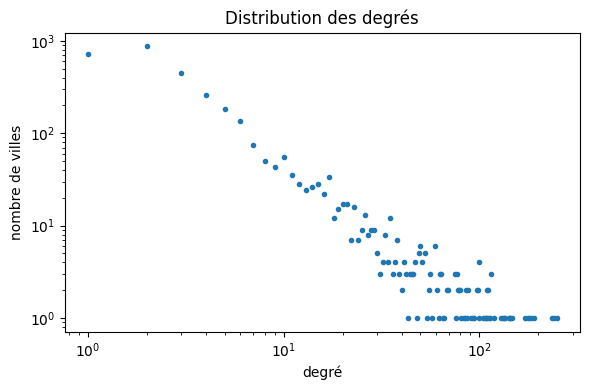

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = deg.value_counts().sort_index()
ax.loglog(vc.index, vc.values, "o", ms=3)
ax.set(title="Distribution des degrés", xlabel="degré", ylabel="nombre de villes")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_degree.png", dpi=120)
plt.show()

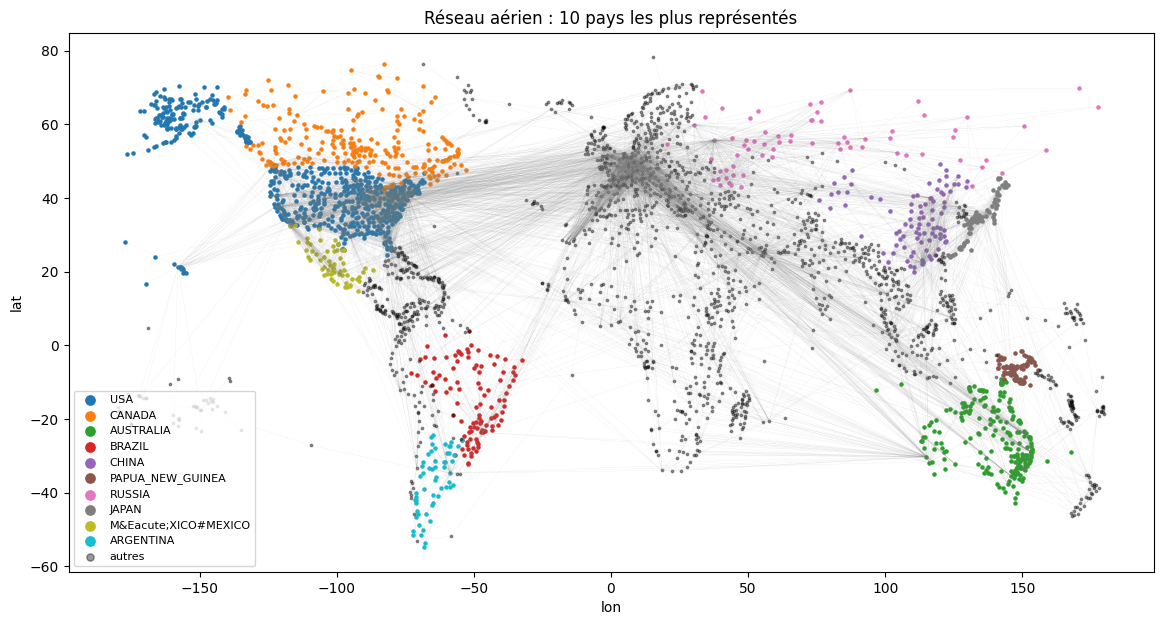

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))
edges = np.array(G.edges)
lon, lat = raw["lon"].values, raw["lat"].values
# Arêtes (sans celles qui traversent l'antiméridien, pour la lisibilité)
short = np.abs(lon[edges[:, 0]] - lon[edges[:, 1]]) < 180
for u, v in edges[short]:
    ax.plot([lon[u], lon[v]], [lat[u], lat[v]], color="grey", lw=.1, alpha=.3)
top = country_counts.index[:10]
for c in top:
    m = raw["country"] == c
    ax.scatter(lon[m], lat[m], s=5, label=c)
m = ~raw["country"].isin(top)
ax.scatter(lon[m], lat[m], s=3, color="black", alpha=.4, label="autres")
ax.set(title="Réseau aérien : 10 pays les plus représentés", xlabel="lon", ylabel="lat")
ax.legend(markerscale=3, fontsize=8, loc="lower left")
plt.savefig(FIG_DIR / "01_map.png", dpi=120)
plt.show()

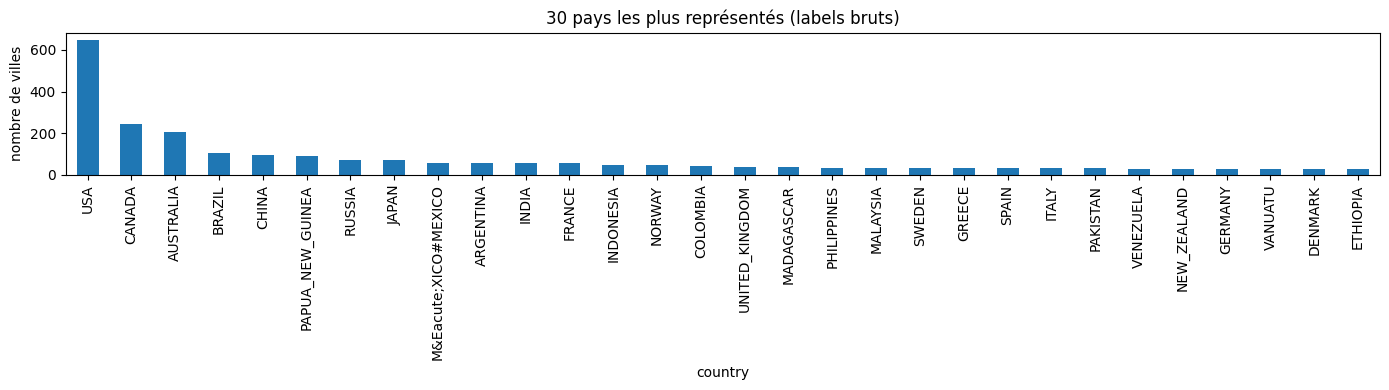

Noms bruités : ["CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC", 'CONGO,_REPUBLIC_OF_THE', 'HA&Iuml;TI#HAITI', 'M&Eacute;XICO#MEXICO', 'PER&Uacute;#PERU', 'SAINT-PIERRE_AND_MIQUELON#ST-PIERRE_AND_MIQUELON', 'SAINT_HELENA#ST_HELENA', 'SAINT_KITTS_AND_NEVIS#ST_KITTS_AND_NEVIS', 'SAINT_LUCIA#ST_LUCIA', 'SAINT_VINCENT_AND_THE_GRENADINES#ST_VINCENT_AND_THE_GRENADINES', 'VI&Ecirc;T_NAM#VIET_NAM,VIETNAM']


In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
country_counts.head(30).plot.bar(ax=ax)
ax.set(title="30 pays les plus représentés (labels bruts)", ylabel="nombre de villes")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_countries.png", dpi=120)
plt.show()

print("Noms bruités :", sorted(c for c in country_counts.index if any(s in c for s in "&#,")))

**Piège 1 — les coordonnées contiennent presque la réponse.** Un 1-NN sur (lat, lon), sans aucune arête,
avec 50 % des nœuds en test :

In [10]:
Xc = raw[["lat", "lon"]].values
tr, te = train_test_split(np.arange(N), test_size=.5, random_state=0)
knn1 = KNeighborsClassifier(1).fit(Xc[tr], raw["country"].values[tr])
print(f"1-NN sur coordonnées : accuracy = {knn1.score(Xc[te], raw['country'].values[te]):.3f}")

1-NN sur coordonnées : accuracy = 0.839


**Deux pièges**
1. Coordonnées quasi-oracles → tout évaluer en **scénario A (avec coords)** et **B (sans coords)**.
2. Labels pays bruités et déséquilibrés → nettoyage, classe `OTHER` pour les pays < 5 villes, **F1-macro** en plus de l'accuracy.

## 2. Nettoyage et préparation des données

### 2.1 Nettoyage des labels de pays
- Si le nom contient `#`, garder la partie après le `#`.
- Si le résultat contient une virgule, garder la première forme.
- Pays avec moins de 5 villes → `OTHER`.

 La règle de la virgule n'est appliquée qu'à la partie après le `#` (liste d'alias).
Appliquée partout, elle fusionnerait `CONGO,_REPUBLIC_OF_THE` et `CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC` en `CONGO`.

In [11]:
def clean_country(name: str) -> str:
    name = html.unescape(name).strip()
    if "#" in name:
        name = name.split("#", 1)[1].split(",", 1)[0]
    return name.strip()


def group_rare(countries, min_count=MIN_CITIES):
    counts = Counter(countries)
    return [c if counts[c] >= min_count else OTHER for c in countries]


for c in ["M&Eacute;XICO#MEXICO", "PER&Uacute;#PERU", "VI&Ecirc;T_NAM#VIET_NAM,VIETNAM",
          "CONGO,_REPUBLIC_OF_THE", "CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC"]:
    print(f"{c:40s} -> {clean_country(c)}")

M&Eacute;XICO#MEXICO                     -> MEXICO
PER&Uacute;#PERU                         -> PERU
VI&Ecirc;T_NAM#VIET_NAM,VIETNAM          -> VIET_NAM
CONGO,_REPUBLIC_OF_THE                   -> CONGO,_REPUBLIC_OF_THE
CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC     -> CONGO,_DEMOCRATIC_PEOPLES'S_REPUBLIC


### 2.2 Features des nœuds

La population n'est jamais utilisée comme feature.

In [12]:
# ==========================================
# 2.2 FONCTIONS DE FEATURES (appliquées dans build_data, cellule suivante)
# ==========================================

def geo_features(lat, lon):
    """(cos lat·cos lon, cos lat·sin lon, sin lat) : pas de discontinuité à ±180°."""
    lat, lon = np.radians(lat), np.radians(lon)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=1)


def structural_features(G):
    """Rôle de la ville dans le réseau (pas sa position). Calcul transductif, sans les labels."""
    n = G.number_of_nodes()
    deg = np.array([G.degree(i) for i in range(n)], dtype=float)
    pr, cl, cc = nx.pagerank(G), nx.clustering(G), nx.closeness_centrality(G)
    feats = np.stack([
        np.log1p(deg),
        np.log([pr[i] for i in range(n)]),   # PageRank très asymétrique -> log
        [cl[i] for i in range(n)],
        [cc[i] for i in range(n)],
    ], axis=1)
    return (feats - feats.mean(0)) / feats.std(0)

### 2.3 Conversion en `torch_geometric.data.Data`

In [13]:
def build_data(G):
    n = G.number_of_nodes()
    attrs = [G.nodes[i] for i in range(n)]
    lat = np.array([a["lat"] for a in attrs], dtype=float)
    lon = np.array([a["lon"] for a in attrs], dtype=float)

    countries = group_rare([clean_country(a["country"]) for a in attrs])
    classes = sorted(set(countries) - {OTHER}) + [OTHER]
    class_idx = {c: i for i, c in enumerate(classes)}

    x_geo = torch.tensor(geo_features(lat, lon), dtype=torch.float)
    x_struct = torch.tensor(structural_features(G), dtype=torch.float)
    edge_index = to_undirected(torch.tensor(list(G.edges)).t(), num_nodes=n)

    data = Data(
        x=torch.cat([x_geo, x_struct], dim=1),   # scénario A
        x_geo=x_geo,
        x_struct=x_struct,                        # scénario B
        edge_index=edge_index,
        y_country=torch.tensor([class_idx[c] for c in countries]),
        num_nodes=n,
    )
    # Métadonnées (jamais utilisées comme features)
    data.country_names = classes
    data.city_name = [a["city_name"] for a in attrs]
    return data


def features(data, scenario):
    return {"A": data.x, "B": data.x_struct}[scenario]


data = build_data(G)
torch.save(data, PROCESSED_DIR / "airports.pt")
NUM_CLASSES = len(data.country_names)

counts = torch.bincount(data.y_country)
print(data)
print(f"Classes pays : {NUM_CLASSES} (OTHER = {counts[-1].item()} villes, "
      f"plus grande classe = {counts.max().item()}, plus petite = {counts.min().item()})")
print(f"Homophilie des arêtes (labels nettoyés) : "
      f"{(data.y_country[data.edge_index[0]] == data.y_country[data.edge_index[1]]).float().mean():.3f}")

Data(x=[3363, 7], edge_index=[2, 27094], x_geo=[3363, 3], x_struct=[3363, 4], y_country=[3363], num_nodes=3363, country_names=[100], city_name=[3363])
Classes pays : 100 (OTHER = 203 villes, plus grande classe = 650, plus petite = 5)
Homophilie des arêtes (labels nettoyés) : 0.592


## 3. Protocole expérimental

- Scénarios : **A** (coords + structure) et **B** (structure seule).
- Taux de labels : 10 %, 30 %, 50 % pour l'entraînement ; val = 10 % ; test = le reste.
- Tous les nœuds sont candidats, découpage **stratifié par pays**.
- Cadre transductif : le graphe complet est toujours visible, seuls les labels sont cachés.
- 10 graines (0…9), résultats en moyenne ± écart-type, early stopping sur la validation (patience = 50).
- Hyperparamètres des GNN : Optuna sur la validation uniquement (plages ci-dessous, utilisées aux étapes suivantes).

In [14]:
from sklearn.model_selection import StratifiedKFold, train_test_split
import numpy as np
import torch

# Définition du nombre de plis (folds) pour la validation croisée
K_FOLDS = 5
VAL_RATE = 0.1  # Part du bloc d'entraînement dédiée à la validation

# Utilisation de StratifiedKFold pour garantir l'équilibre des classes (pays) dans chaque fold
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

all_nodes = np.arange(data.num_nodes)
y_country = data.y_country.numpy()

splits = {}

# Boucle sur chaque fold
for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(all_nodes, y_country)):
    
    # Dans le bloc d'entraînement/validation, on isole une partie pour la validation (ex: 10% du total)
    # On utilise aussi train_test_split avec stratification pour ce sous-ensemble
    relative_val_size = VAL_RATE / (1.0 - (1.0 / K_FOLDS))
    
    try:
        train_idx, val_idx = train_test_split(
            train_val_idx, 
            test_size=relative_val_size, 
            random_state=42, 
            stratify=y_country[train_val_idx]
        )
    except ValueError:
        # Fallback aléatoire si la stratification échoue sur un petit groupe
        train_idx, val_idx = train_test_split(
            train_val_idx, 
            test_size=relative_val_size, 
            random_state=42
        )

    # Stockage au format attendu par ton pipeline (sous forme de tenseurs triés)
    splits[fold_idx] = {
        "train": torch.from_numpy(np.sort(train_idx)),
        "val": torch.from_numpy(np.sort(val_idx)),
        "test": torch.from_numpy(np.sort(test_idx))
    }

# Sauvegarde des splits K-Fold
torch.save(splits, PROCESSED_DIR / "splits_kfold.pt")

# Affichage d'un récapitulatif pour vérifier les tailles
pd.DataFrame([
    {
        "fold": f, 
        **{k: len(v) for k, v in splits[f].items()},
        "classes vues en train": len(set(data.y_country[splits[f]["train"]].tolist()))
    }
    for f in range(K_FOLDS)
])

,fold,train,val,test,classes vues en train
0,0,2353,337,673,100
1,1,2353,337,673,100
2,2,2353,337,673,100
3,3,2354,337,672,100
4,4,2354,337,672,100


## 4. Baselines



Les baselines qui n'utilisent pas les features (majoritaire, Label Propagation, Node2Vec) donnent le même
score dans les deux scénarios : elles sont calculées une fois et reportées en A et en B.
Leurs quelques hyperparamètres (k, α, C…) sont choisis sur la validation par petite grille.

Métriques : accuracy et F1-macro.

In [15]:
OTHER_IDX = len(data.country_names) - 1   # build_data place OTHER en dernier

# Critère de sélection sur la validation : choix des hyperparamètres ET early stopping
SELECTION_METRIC = "f1_macro"             # "f1_macro" (métrique principale) ou "acc"

# Taille de chaque pays sur tout le graphe -> 3 groupes (OTHER exclu)
CLASS_SIZE = np.bincount(data.y_country.numpy(), minlength=NUM_CLASSES)
SIZE_GROUPS = {
    "f1_grands": [c for c in range(OTHER_IDX) if CLASS_SIZE[c] >= 50],
    "f1_moyens": [c for c in range(OTHER_IDX) if 20 <= CLASS_SIZE[c] < 50],
    "f1_petits": [c for c in range(OTHER_IDX) if CLASS_SIZE[c] < 20],
}
print("Pays par groupe :", {k: len(v) for k, v in SIZE_GROUPS.items()})   # attendu : 12 / 29 / 58


def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    hors_other = y_true != OTHER_IDX
    res = {
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "acc_sans_other": accuracy_score(y_true[hors_other], y_pred[hors_other]),
        "f1_macro_sans_other": f1_score(y_true, y_pred, labels=list(range(OTHER_IDX)),
                                        average="macro", zero_division=0),
    }
    for name, labels in SIZE_GROUPS.items():      # F1-macro restreint aux pays du groupe
        res[name] = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    return res


def f1_macro_fast(y_true, y_pred):
    """Même valeur que f1_score(average="macro"), en numpy pur (appelée à chaque époque).
    F1_c = 2 TP_c / (n_vrais_c + n_prédits_c), moyenne sur les classes présentes dans y_true ou y_pred."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    labels = np.union1d(y_true, y_pred)
    n = max(NUM_CLASSES, int(labels.max()) + 1)
    tp = np.bincount(y_true[y_true == y_pred], minlength=n)[labels]
    n_true = np.bincount(y_true, minlength=n)[labels]
    n_pred = np.bincount(y_pred, minlength=n)[labels]
    return float(np.mean(2 * tp / (n_true + n_pred)))


def val_score(y_true, y_pred):
    """Critère de sélection sur la validation (SELECTION_METRIC)."""
    if SELECTION_METRIC == "f1_macro":
        return f1_macro_fast(y_true, y_pred)
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def select_on_val(split, candidates):
    """
    candidates : dict nom -> prédictions sur tous les nœuds.
    Retourne les métriques test du meilleur candidat selon val_score.
    """
    y = data.y_country.numpy()
    va, te = split["val"].numpy(), split["test"].numpy()
    best = max(candidates, key=lambda k: val_score(y[va], candidates[k][va]))
    return evaluate(y[te], candidates[best][te]), best

Pays par groupe : {'f1_grands': 12, 'f1_moyens': 29, 'f1_petits': 58}


### 4.1 Classe majoritaire

In [16]:
def run_majority(split):
    y = data.y_country.numpy()
    tr, te = split["train"].numpy(), split["test"].numpy()
    return evaluate(y[te], np.full(len(te), np.bincount(y[tr]).argmax())), "-"

In [17]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim)
        )

    def forward(self, x):
        return self.net(x)


def run_mlp(split, scenario, seed=0, hidden=64, dropout=0.3, lr=1e-2, wd=5e-4, max_epochs=2000):
    set_seed(seed)                                  # même graine -> mêmes poids initiaux et même dropout
    x, y = features(data, scenario), data.y_country
    # ... le reste de la fonction est inchangé ...
    
    # Récupération des indices depuis le split du K-Fold
    tr, va, te = split["train"], split["val"], split["test"]
    
    model = MLP(x.size(1), hidden, NUM_CLASSES, dropout)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    def predict():
        model.eval()
        with torch.no_grad():
            # Utilisation de .cpu().numpy() pour éviter les erreurs si x est sur GPU
            return model(x).argmax(1).cpu().numpy()

    best, best_pred, wait = -np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        loss = F.cross_entropy(model(x[tr]), y[tr])
        loss.backward()
        opt.step()

        pred = predict()
        score = val_score(y[va].cpu().numpy(), pred[va])
        
        if score > best:
            best, best_pred, wait = score, pred, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
                
    return evaluate(y[te].cpu().numpy(), best_pred[te]), f"epochs={epoch + 1}"

### 4.3 k-NN sur coordonnées (scénario A uniquement)

In [18]:
def run_knn(split):
    x = data.x_geo.numpy()   # distance euclidienne en (x, y, z)
    y = data.y_country.numpy()
    tr = split["train"].numpy()
    candidates = {}
    for k in (1, 3, 5, 10, 20):
        for w in ("uniform", "distance"):
            if k <= len(tr):
                candidates[f"k={k},{w}"] = KNeighborsClassifier(k, weights=w).fit(x[tr], y[tr]).predict(x)
    return select_on_val(split, candidates)

### 4.4 Label Propagation (graphe seul)

In [19]:
def run_label_propagation(split):
    y = data.y_country
    mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    mask[split["train"]] = True
    candidates = {}
    for alpha in (0.5, 0.7, 0.9, 0.99):
        out = LabelPropagation(num_layers=50, alpha=alpha)(y, data.edge_index, mask=mask)
        pred = out.argmax(1).numpy()
        pred[split["train"].numpy()] = y[split["train"]].numpy()
        candidates[f"alpha={alpha}"] = pred
    return select_on_val(split, candidates)

### 4.5 Node2Vec + régression logistique

Les embeddings sont non supervisés (ils ne dépendent pas des labels) : un embedding par graine, mis en cache.
Marches uniformes (p = q = 1, équivalent DeepWalk) : l'échantillonneur de `pyg_lib` ne gère pas encore les marches biaisées.

In [20]:
N2V_CFG = dict(embedding_dim=128, walk_length=20, context_size=10, walks_per_node=20,
               num_negative_samples=1, p=1.0, q=1.0)
N2V_EPOCHS = 30


def node2vec_embedding(cfg=N2V_CFG, epochs=N2V_EPOCHS, seed=SEED):
    """Embedding non supervisé (n'utilise aucun label) : un seul pour tous les plis."""
    tag = "_".join(f"{k}{v}" for k, v in cfg.items()) + f"_ep{epochs}_s{seed}"
    path = PROCESSED_DIR / f"node2vec_{tag}.pt"     # le nom change si un hyperparamètre change
    if path.exists():
        return torch.load(path)

    set_seed(seed)
    model = Node2Vec(data.edge_index, num_nodes=data.num_nodes, sparse=True, **cfg)
    loader = model.loader(batch_size=128, shuffle=True)
    opt = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)
    model.train()
    for epoch in range(epochs):
        total = 0.0
        for pos_rw, neg_rw in loader:
            opt.zero_grad()
            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            opt.step()
            total += loss.item()
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Node2Vec epoch {epoch:3d} | loss {total / len(loader):.4f}")

    emb = model.embedding.weight.detach().cpu().clone()
    torch.save(emb, path)
    return emb


def run_node2vec(split, emb):
    """Deux familles de classifieurs sur l'embedding, choisies sur la validation."""
    y = data.y_country.numpy()
    tr = split["train"].numpy()
    z = StandardScaler().fit_transform(emb.numpy())
    candidates = {}
    for c in (0.01, 0.1, 1.0, 10.0):
        m = LogisticRegression(C=c, max_iter=2000).fit(z[tr], y[tr])
        candidates[f"LogReg C={c}"] = m.predict(z)
    for k in (1, 3, 5, 10):
        for w in ("uniform", "distance"):
            m = KNeighborsClassifier(k, weights=w, metric="cosine").fit(emb.numpy()[tr], y[tr])
            candidates[f"kNN-cos k={k},{w}"] = m.predict(emb.numpy())
    return select_on_val(split, candidates)

### 4.6 Lancement de toutes les baselines

In [21]:
rows = []

def record(scenarios, model, fold_idx, result):
    metrics, chosen = result
    for sc in scenarios:
        rows.append({"scenario": sc, "model": model, "fold": fold_idx,
                     "selected": chosen, **metrics})

t0 = time.time()

# Un seul embedding Node2Vec pour tous les plis (il n'utilise aucun label)
EMB_N2V = node2vec_embedding()                                              # <-- MODIFIÉ
print(f"Embedding Node2Vec prêt ({time.time() - t0:.0f} s)")

# Boucle principale d'évaluation sur le K-Fold
for fold_idx, split in splits.items():
    # 1. Classe majoritaire
    record(SCENARIOS, "Majoritaire", fold_idx, run_majority(split))

    # 2. MLP sur les features (scénarios A et B), graine = numéro du pli
    for sc in SCENARIOS:
        record([sc], "MLP", fold_idx, run_mlp(split, sc, seed=fold_idx))    # <-- MODIFIÉ

    # 3. k-NN sur coordonnées (scénario A uniquement)
    record(["A"], "k-NN (coords)", fold_idx, run_knn(split))

    # 4. Label Propagation (graphe seul)
    record(SCENARIOS, "Label Propagation", fold_idx, run_label_propagation(split))

    # 5. Node2Vec + classifieur (LogReg ou k-NN cosinus, choisi sur la validation)
    record(SCENARIOS, "Node2Vec", fold_idx, run_node2vec(split, EMB_N2V))   # <-- MODIFIÉ

    print(f"Fold {fold_idx + 1}/{K_FOLDS} terminé ({time.time() - t0:.0f} s)")

raw_results = pd.DataFrame(rows)
raw_results.to_csv(RESULTS_DIR / "baselines_raw_kfold.csv", index=False)
raw_results.head()

Node2Vec epoch   0 | loss 8.0419
Node2Vec epoch   5 | loss 2.0060
Node2Vec epoch  10 | loss 1.1104
Node2Vec epoch  15 | loss 0.9502
Node2Vec epoch  20 | loss 0.9076
Node2Vec epoch  25 | loss 0.8917
Node2Vec epoch  29 | loss 0.8855
Embedding Node2Vec prêt (828 s)
Fold 1/5 terminé (870 s)
Fold 2/5 terminé (914 s)
Fold 3/5 terminé (943 s)
Fold 4/5 terminé (985 s)
Fold 5/5 terminé (1008 s)


,scenario,model,fold,selected,acc,f1_macro,acc_sans_other,f1_macro_sans_other,f1_grands,f1_moyens,f1_petits
0,A,Majoritaire,0,-,0.193165,0.003238,0.205696,0.003271,0.026982,0.000000,0.000000
1,B,Majoritaire,0,-,0.193165,0.003238,0.205696,0.003271,0.026982,0.000000,0.000000
2,A,MLP,0,epochs=286,0.775632,0.495180,0.802215,0.495914,0.868628,0.734418,0.299548
3,B,MLP,0,epochs=305,0.289747,0.059498,0.292722,0.057879,0.229295,0.102706,0.000000
4,A,k-NN (coords),0,"k=3,distance",0.894502,0.787980,0.911392,0.789118,0.916690,0.893138,0.710714


### 4.7 Résultats (moyenne ± écart-type sur 10 graines, ensemble de test)

In [22]:
# ==========================================
# DIAGNOSTIC NODE2VEC : l'embedding capte-t-il le pays ou seulement la région ?
# ==========================================
from sklearn.neighbors import NearestNeighbors

def haversine_km(lat1, lon1, lat2, lon2):
    """Distance sur la sphère terrestre (rayon 6 371 km)."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

K_NB = 5
y = data.y_country.numpy()
lat, lon, deg = raw["lat"].values, raw["lon"].values, raw["degree"].values
emb = EMB_N2V.numpy()

# 5 plus proches voisins de chaque ville dans l'espace Node2Vec (similarité cosinus)
nn_model = NearestNeighbors(n_neighbors=K_NB + 1, metric="cosine").fit(emb)
_, idx = nn_model.kneighbors(emb)
idx = idx[:, 1:]                                    # on retire la ville elle-même

# Référence : 5 villes tirées au hasard pour chaque ville
rng = np.random.default_rng(SEED)
rand_idx = rng.integers(0, len(y), size=idx.shape)

def describe(neigh, name):
    return {"voisins": name,
            "même pays (%)": 100 * (y[neigh] == y[:, None]).mean(),
            "distance médiane (km)": np.median(haversine_km(lat[:, None], lon[:, None], lat[neigh], lon[neigh]))}

# Tableau 1 : voisins Node2Vec vs villes au hasard
display(pd.DataFrame([describe(idx, "5 plus proches dans Node2Vec"),
                      describe(rand_idx, "5 villes au hasard")]).round(1))

# Tableau 2 : même mesure selon le degré de la ville (petits aéroports vs hubs)
tranche = pd.cut(deg, [0, 1, 3, 10, 50, 300], labels=["1", "2-3", "4-10", "11-50", ">50"])
par_degre = pd.DataFrame({
    "tranche de degré": tranche,
    "même pays (%)": 100 * (y[idx] == y[:, None]).mean(1),
    "distance médiane (km)": np.median(haversine_km(lat[:, None], lon[:, None], lat[idx], lon[idx]), axis=1),
}).groupby("tranche de degré", observed=True).agg(["mean", "count"]).round(1)
display(par_degre)

,voisins,même pays (%),distance médiane (km)
0,5 plus proches dans Node2Vec,81.1,460.8
1,5 villes au hasard,5.7,8948.0


même pays (%)       distance médiane (km)      
                          mean count                  mean count
tranche de degré                                                
1                         80.3   725                1203.4   725
2-3                       84.7  1314                 846.8  1314
4-10                      83.6   800                 828.0   800
11-50                     71.7   424                1163.3   424
>50                       59.2   100                 976.5   100

In [23]:
MODEL_ORDER = ["Majoritaire", "MLP", "k-NN (coords)", "Label Propagation", "Node2Vec"]
METRICS = ("f1_macro", "acc", "f1_grands", "f1_moyens", "f1_petits", "acc_sans_other", "f1_macro_sans_other")


def summary_table(metric):
    g = raw_results.groupby(["scenario", "model"])[metric].agg(["mean", "std"]).reset_index()
    g["result"] = g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)
    pivot_df = g.pivot(index="model", columns="scenario", values="result")
    return pivot_df.reindex([m for m in MODEL_ORDER if m in pivot_df.index])


summary = []
for metric in METRICS:
    t = summary_table(metric)
    summary.append(t.assign(metric=metric))
    print(f"\n=== T1 — {metric} (validation croisée 5 plis) ===")
    display(t)

pd.concat(summary).to_csv(RESULTS_DIR / "baselines_summary_kfold.csv")


=== T1 — f1_macro (validation croisée 5 plis) ===


scenario,A,B
model,,
Majoritaire,0.003 ± 0.000,0.003 ± 0.000
MLP,0.496 ± 0.031,0.054 ± 0.015
k-NN (coords),0.773 ± 0.018,NaN
Label Propagation,0.831 ± 0.015,0.831 ± 0.015
Node2Vec,0.781 ± 0.024,0.781 ± 0.024



=== T1 — acc (validation croisée 5 plis) ===


scenario,A,B
model,,
Majoritaire,0.193 ± 0.000,0.193 ± 0.000
MLP,0.770 ± 0.016,0.282 ± 0.018
k-NN (coords),0.880 ± 0.009,NaN
Label Propagation,0.898 ± 0.007,0.898 ± 0.007
Node2Vec,0.871 ± 0.004,0.871 ± 0.004



=== T1 — f1_grands (validation croisée 5 plis) ===


...

scenario,A,B
model,,
Majoritaire,0.000 ± 0.000,0.000 ± 0.000
MLP,0.306 ± 0.043,0.004 ± 0.005
k-NN (coords),0.700 ± 0.029,NaN
Label Propagation,0.775 ± 0.026,0.775 ± 0.026
Node2Vec,0.710 ± 0.047,0.710 ± 0.047



=== T1 — acc_sans_other (validation croisée 5 plis) ===


scenario,A,B
model,,
Majoritaire,0.206 ± 0.000,0.206 ± 0.000
MLP,0.796 ± 0.013,0.285 ± 0.016
k-NN (coords),0.903 ± 0.009,NaN
Label Propagation,0.912 ± 0.011,0.912 ± 0.011
Node2Vec,0.894 ± 0.005,0.894 ± 0.005



=== T1 — f1_macro_sans_other (validation croisée 5 plis) ===


scenario,A,B
model,,
Majoritaire,0.003 ± 0.000,0.003 ± 0.000
MLP,0.496 ± 0.031,0.053 ± 0.015
k-NN (coords),0.775 ± 0.017,NaN
Label Propagation,0.832 ± 0.016,0.832 ± 0.016
Node2Vec,0.784 ± 0.025,0.784 ± 0.025


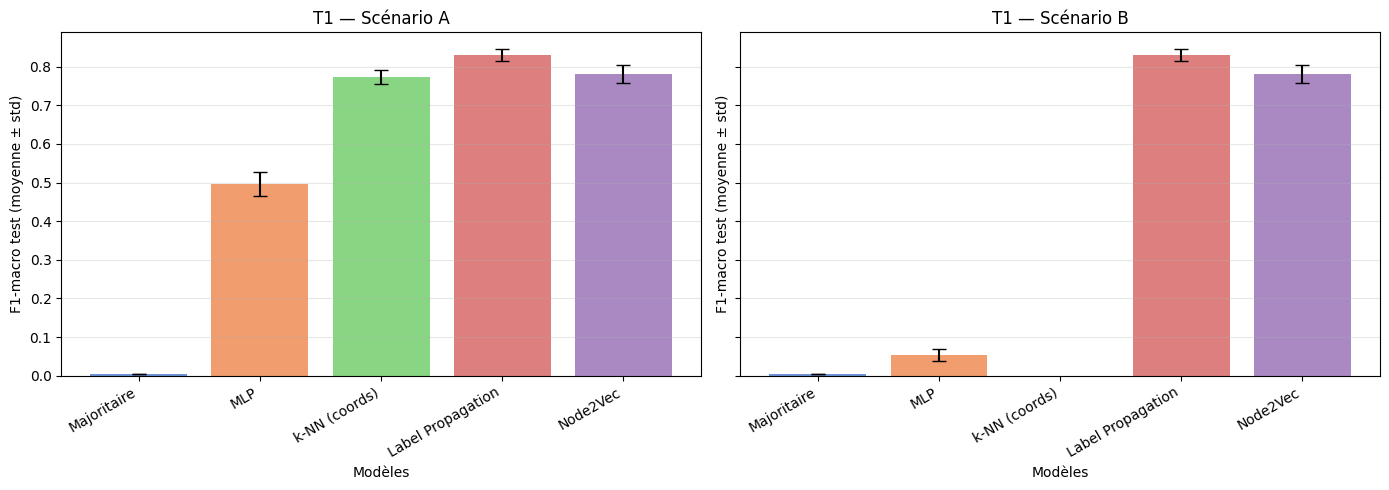

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
df = raw_results

for ax, sc in zip(axes, SCENARIOS):
    # F1-macro moyen et écart-type sur les 5 plis, par modèle
    g = df[df.scenario == sc].groupby("model")["f1_macro"].agg(["mean", "std"]).reindex(MODEL_ORDER).reset_index()
    ax.bar(g["model"], g["mean"], yerr=g["std"], capsize=5,
           color=sns.color_palette("muted", len(MODEL_ORDER)), alpha=0.8)
    ax.set(title=f"T1 — Scénario {sc}", xlabel="Modèles", ylabel="F1-macro test (moyenne ± std)")
    ax.set_xticklabels(g["model"], rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_baselines_t1_kfold.png", dpi=120)
plt.show()

In [25]:
raw_results.query("model == 'Node2Vec' and scenario == 'A'")[["fold", "selected", "acc", "f1_macro"]]

,fold,selected,acc,f1_macro
7,0,"kNN-cos k=3,distance",0.872214,0.818128
16,1,"kNN-cos k=5,uniform",0.869242,0.776114
25,2,"kNN-cos k=5,distance",0.878158,0.753376
34,3,"kNN-cos k=3,distance",0.870536,0.769894
43,4,"kNN-cos k=3,uniform",0.866071,0.789029


In [26]:
# ==========================================
# ABLATION NODE2VEC : embedding (ancien / nouveau) x classifieur (LogReg / k-NN cosinus)
# ==========================================
N2V_CFG_OLD = dict(embedding_dim=64, walk_length=20, context_size=10, walks_per_node=10,
                   num_negative_samples=1, p=1.0, q=1.0)
EMB_N2V_OLD = node2vec_embedding(cfg=N2V_CFG_OLD, epochs=10)   # ancienne configuration (mise en cache)


def best_on_val(split, emb, family):
    """Meilleur classifieur d'une seule famille, choisi sur la validation, évalué sur le test."""
    y = data.y_country.numpy()
    tr = split["train"].numpy()
    candidates = {}
    if family == "LogReg":
        z = StandardScaler().fit_transform(emb.numpy())
        for c in (0.01, 0.1, 1.0, 10.0):
            candidates[f"C={c}"] = LogisticRegression(C=c, max_iter=2000).fit(z[tr], y[tr]).predict(z)
    else:
        for k in (1, 3, 5, 10):
            for w in ("uniform", "distance"):
                candidates[f"k={k},{w}"] = KNeighborsClassifier(k, weights=w, metric="cosine") \
                    .fit(emb.numpy()[tr], y[tr]).predict(emb.numpy())
    metrics, _ = select_on_val(split, candidates)
    return metrics


abl_rows = []
for fold_idx, split in splits.items():
    for emb_name, emb in [("ancien (64d, 10 ép.)", EMB_N2V_OLD), ("nouveau (128d, 30 ép.)", EMB_N2V)]:
        for family in ("LogReg", "kNN-cos"):
            m = best_on_val(split, emb, family)
            abl_rows.append({"embedding": emb_name, "classifieur": family, "fold": fold_idx, **m})

abl = pd.DataFrame(abl_rows)
for metric in ("acc", "f1_macro"):
    g = abl.groupby(["embedding", "classifieur"])[metric].agg(["mean", "std"])
    t = (g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)).unstack("classifieur")
    print(f"\n=== Ablation Node2Vec — {metric} ===")
    display(t)

Node2Vec epoch   0 | loss 5.6137
Node2Vec epoch   5 | loss 1.5630
Node2Vec epoch   9 | loss 1.0857

=== Ablation Node2Vec — acc ===


classifieur,LogReg,kNN-cos
embedding,,
"ancien (64d, 10 ép.)",0.478 ± 0.044,0.416 ± 0.026
"nouveau (128d, 30 ép.)",0.839 ± 0.018,0.871 ± 0.004



=== Ablation Node2Vec — f1_macro ===


classifieur,LogReg,kNN-cos
embedding,,
"ancien (64d, 10 ép.)",0.228 ± 0.018,0.156 ± 0.028
"nouveau (128d, 30 ép.)",0.735 ± 0.026,0.781 ± 0.024


## 5. partie GNN


### Conclusions pour la suite (GNN)

- **Scénario A** : l'objectif est de battre 0.885 / F1 0.802 (Label Propagation), pas seulement le k-NN. Un GNN qui combine coordonnées et passage de messages devrait pouvoir cumuler les deux signaux.
- **Scénario B** : c'est là qu'un GNN a le plus à prouver. Il part des mêmes features que le MLP (0.26) et doit se rapprocher de la Label Propagation. Des architectures qui propagent bien les labels, comme APPNP ou un GCN combiné à de la Label Propagation (C&S), sont de bons candidats.
- **Limites des baselines** : les hyperparamètres sont choisis sur une petite grille et le MLP n'est pas passé par Optuna. Il faudra appliquer la même recherche Optuna aux baselines et aux GNN pour que la comparaison soit équitable.

In [27]:
from torch_geometric.nn import GCNConv

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)


class GCN(nn.Module):
    """GCN du cours (slide 13) : [Dropout -> GCNConv -> ReLU] x (L-1), puis Dropout -> GCNConv -> logits.
    Si in_dim est None, l'entrée est l'identité : X W = W, réalisé par une table d'embeddings."""
    def __init__(self, in_dim, hidden, out_dim, num_layers=2, dropout=0.5, num_nodes=None):
        super().__init__()
        self.emb = None
        if in_dim is None:                          # entrée identité (one-hot par ville)
            self.emb = nn.Embedding(num_nodes, hidden)
            in_dim = hidden
        dims = [in_dim] + [hidden] * (num_layers - 1) + [out_dim]
        # cached=True : D^-1/2 Â D^-1/2 calculée une seule fois (graphe fixe, transductif)
        self.convs = nn.ModuleList(
            [GCNConv(dims[i], dims[i + 1], cached=True) for i in range(num_layers)]
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        if self.emb is not None:
            x = self.emb.weight                     # une ligne apprise par ville
        for i, conv in enumerate(self.convs):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:             # pas de ReLU sur la sortie : ce sont des logits
                x = F.relu(x)
        return x


def train_node_model(model, x, split, lr, wd, max_epochs=1000, class_weight=False):
    """Plein batch ; early stopping sur val_score (même critère que les baselines)."""
    model = model.to(DEVICE)
    y = data.y_country.to(DEVICE)
    ei = data.edge_index.to(DEVICE)
    x = x.to(DEVICE) if x is not None else None
    tr = split["train"].to(DEVICE)
    va_np = split["val"].numpy()
    y_va = data.y_country.numpy()[va_np]

    weight = None
    if class_weight:                                # w_c = N_train / (C * n_c)
        counts = torch.bincount(y[tr], minlength=NUM_CLASSES).float()
        weight = counts.sum() / (NUM_CLASSES * counts.clamp(min=1))

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    best_val, best_pred, wait = -np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        out = model(x, ei)                          # forward sur TOUS les nœuds
        loss = F.cross_entropy(out[tr], y[tr], weight=weight)   # loss sur le train seulement
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(x, ei).argmax(1).cpu().numpy()
        score = val_score(y_va, pred[va_np])
        if score > best_val:
            best_val, best_pred, wait = score, pred, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    return best_val, best_pred, epoch + 1

Device : cuda


In [28]:
# Les 4 entrées du GCN (calculées une seule fois)
GNN_INPUTS = {
    "A": data.x,                                    # coordonnées 3D + structure (7 features)
    "B": data.x_struct,                             # structure seule (4 features)
    "B+id": torch.eye(data.num_nodes),              # identité : un one-hot par ville (3363 features)
    "B+n2v": torch.tensor(StandardScaler().fit_transform(EMB_N2V.numpy()),
                          dtype=torch.float),       # embedding Node2Vec (128 features)
}

# Petite grille, choisie sur la validation pour chaque pli
GCN_GRID = [dict(hidden=h, dropout=d, num_layers=L)
            for h in (64, 128) for d in (0.3, 0.5) for L in (2, 3)]


def run_gcn(split, scenario, seed=0, lr=1e-2, wd=5e-4):
    x = GNN_INPUTS[scenario]
    y = data.y_country.numpy()
    best = None
    for cfg in GCN_GRID:
        set_seed(seed)                              # même initialisation pour chaque config -> comparaison juste
        model = GCN(x.size(1), cfg["hidden"], NUM_CLASSES, cfg["num_layers"], cfg["dropout"])
        val_acc, pred, n_ep = train_node_model(model, x, split, lr, wd)
        if best is None or val_acc > best[0]:
            best = (val_acc, pred,
                    f"h={cfg['hidden']},d={cfg['dropout']},L={cfg['num_layers']},ep={n_ep}")
    _, pred, chosen = best
    te = split["test"].numpy()
    return evaluate(y[te], pred[te]), chosen

In [29]:
GNN_SCENARIOS = ["A", "B", "B+id", "B+n2v"]
gnn_rows = []
t0 = time.time()

for fold_idx, split in splits.items():
    for sc in GNN_SCENARIOS:
        metrics, chosen = run_gcn(split, sc, seed=fold_idx)
        gnn_rows.append({"scenario": sc, "model": "GCN", "fold": fold_idx,
                         "selected": chosen, **metrics})
    print(f"Fold {fold_idx + 1}/{K_FOLDS} terminé ({time.time() - t0:.0f} s)")

gnn_results = pd.DataFrame(gnn_rows)
gnn_results.to_csv(RESULTS_DIR / "gcn_raw_kfold.csv", index=False)

# Résumé : moyenne ± écart-type sur les 5 plis
for metric in ("acc", "f1_macro", "acc_sans_other"):
    g = gnn_results.groupby("scenario")[metric].agg(["mean", "std"]).reindex(GNN_SCENARIOS)
    print(f"\n=== GCN — {metric} ===")
    display((g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)).to_frame(metric))

# Configurations choisies par la validation
display(gnn_results[["scenario", "fold", "selected"]].pivot(index="fold", columns="scenario", values="selected"))

Fold 1/5 terminé (40 s)
Fold 2/5 terminé (77 s)
Fold 3/5 terminé (115 s)
Fold 4/5 terminé (156 s)
Fold 5/5 terminé (195 s)

=== GCN — acc ===


,acc
scenario,
A,0.735 ± 0.017
B,0.402 ± 0.022
B+id,0.871 ± 0.011
B+n2v,0.898 ± 0.005



=== GCN — f1_macro ===


,f1_macro
scenario,
A,0.503 ± 0.033
B,0.126 ± 0.020
B+id,0.745 ± 0.030
B+n2v,0.826 ± 0.011



=== GCN — acc_sans_other ===


,acc_sans_other
scenario,
A,0.763 ± 0.016
B,0.404 ± 0.022
B+id,0.885 ± 0.014
B+n2v,0.917 ± 0.005


scenario,A,B,B+id,B+n2v
fold,,,,
0,"h=128,d=0.3,L=3,ep=397","h=128,d=0.3,L=3,ep=327","h=64,d=0.3,L=3,ep=321","h=64,d=0.3,L=2,ep=329"
1,"h=128,d=0.3,L=3,ep=208","h=128,d=0.3,L=3,ep=289","h=128,d=0.3,L=3,ep=230","h=128,d=0.5,L=2,ep=225"
2,"h=128,d=0.3,L=3,ep=297","h=128,d=0.3,L=3,ep=259","h=64,d=0.3,L=3,ep=291","h=64,d=0.3,L=2,ep=292"
3,"h=128,d=0.3,L=3,ep=274","h=128,d=0.3,L=3,ep=308","h=64,d=0.3,L=3,ep=328","h=128,d=0.3,L=3,ep=162"
4,"h=128,d=0.3,L=3,ep=130","h=128,d=0.3,L=3,ep=220","h=128,d=0.3,L=3,ep=275","h=128,d=0.3,L=3,ep=225"


In [30]:
# ==========================================
# DIAGNOSTIC : où le GCN-A perd-il face au MLP-A ? (pli 0)
# ==========================================
class MLPGraph(nn.Module):
    """Le MLP des baselines, avec la signature (x, edge_index) pour réutiliser train_node_model."""
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.mlp = MLP(in_dim, hidden, out_dim, dropout)

    def forward(self, x, edge_index):           # les arêtes sont ignorées
        return self.mlp(x)


split0 = splits[0]
te = split0["test"].numpy()
y = data.y_country.numpy()
deg = raw["degree"].values
tranche = pd.cut(deg, [0, 1, 3, 10, 50, 300], labels=["1", "2-3", "4-10", "11-50", ">50"])

preds = {}
set_seed(0)
_, preds["MLP (A)"], _ = train_node_model(MLPGraph(data.x.size(1), 64, NUM_CLASSES, 0.3),
                                          data.x, split0, 1e-2, 5e-4)
for L in (1, 2, 3):
    set_seed(0)
    _, preds[f"GCN (A) L={L}"], _ = train_node_model(GCN(data.x.size(1), 128, NUM_CLASSES, L, 0.3),
                                                     data.x, split0, 1e-2, 5e-4)

# Tableau 1 : accuracy par tranche de degré (villes de test du pli 0)
rows_diag = []
for name, p in preds.items():
    ok = p[te] == y[te]
    for t in tranche.categories:
        m = np.asarray(tranche[te] == t)
        rows_diag.append({"modèle": name, "tranche de degré": t, "accuracy": ok[m].mean()})
diag = pd.DataFrame(rows_diag).pivot(index="tranche de degré", columns="modèle", values="accuracy")
diag["villes de test"] = pd.Series(np.asarray(tranche[te])).value_counts().reindex(diag.index).values
display(diag.round(3))

# Tableau 2 : métriques globales de chaque modèle sur ce pli
display(pd.DataFrame({name: evaluate(y[te], p[te]) for name, p in preds.items()}).T.round(3))

modèle,GCN (A) L=1,GCN (A) L=2,GCN (A) L=3,MLP (A),villes de test
tranche de degré,,,,,
1,0.298,0.624,0.709,0.745,141
11-50,0.378,0.522,0.578,0.689,90
2-3,0.284,0.659,0.750,0.799,264
4-10,0.291,0.734,0.842,0.778,158
>50,0.350,0.550,0.650,0.650,20


,acc,f1_macro,acc_sans_other,f1_macro_sans_other,f1_grands,f1_moyens,f1_petits
MLP (A),0.764,0.498,0.791,0.499,0.859,0.714,0.317
GCN (A) L=1,0.303,0.029,0.296,0.028,0.218,0.005,0.000
GCN (A) L=2,0.648,0.300,0.676,0.300,0.767,0.509,0.100
GCN (A) L=3,0.737,0.489,0.771,0.491,0.845,0.678,0.324


In [31]:
# ==========================================
# DIAGNOSTIC : accuracy selon l'homophilie locale (pli 0)
# Analyse après coup : les vrais labels servent seulement à DÉCRIRE les villes, jamais au modèle.
# ==========================================
src, dst = data.edge_index.numpy()
same = (y[src] == y[dst]).astype(float)
deg_all = np.bincount(src, minlength=data.num_nodes)
h_loc = np.bincount(src, weights=same, minlength=data.num_nodes) / np.maximum(deg_all, 1)

tranche_h = pd.cut(h_loc, [-0.001, 0.0, 0.5, 0.999, 1.0],
                   labels=["0 : aucun voisin du pays", "]0 ; 0,5]", "]0,5 ; 1[", "1 : tous du pays"])

rows_h = []
for name in ["MLP (A)", "GCN (A) L=3"]:
    ok = preds[name][te] == y[te]
    for t in tranche_h.categories:
        m = np.asarray(tranche_h[te] == t)
        rows_h.append({"modèle": name, "homophilie locale": t,
                       "accuracy": ok[m].mean() if m.any() else np.nan})
diag_h = pd.DataFrame(rows_h).pivot(index="homophilie locale", columns="modèle", values="accuracy")
diag_h["villes de test"] = pd.Series(np.asarray(tranche_h[te])).value_counts().reindex(diag_h.index).values
diag_h["écart GCN - MLP"] = diag_h["GCN (A) L=3"] - diag_h["MLP (A)"]
display(diag_h.round(3))

modèle,GCN (A) L=3,MLP (A),villes de test,écart GCN - MLP
homophilie locale,,,,
0 : aucun voisin du pays,0.026,0.553,38,-0.526
1 : tous du pays,0.847,0.838,451,0.009
"]0 ; 0,5]",0.356,0.389,90,-0.033
"]0,5 ; 1[",0.862,0.851,94,0.011


In [32]:
# ==========================================
# FEATURE ENGINEERING (pli 0) : features de distance et features propagées
# Aucune feature n'utilise les labels.
# ==========================================
from torch_geometric.utils import add_self_loops, degree

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

N_ = data.num_nodes
lat_r, lon_r = raw["lat"].values, raw["lon"].values
src, dst = data.edge_index.numpy()

# 1) Features de distance aux voisins (coordonnées + arêtes, sans labels)
dist = haversine_km(lat_r[src], lon_r[src], lat_r[dst], lon_r[dst])
deg_ = np.maximum(np.bincount(src, minlength=N_), 1)
mean_d = np.bincount(src, weights=dist, minlength=N_) / deg_
min_d = pd.Series(dist).groupby(src).min().reindex(range(N_), fill_value=0).values
share_500 = np.bincount(src, weights=(dist < 500).astype(float), minlength=N_) / deg_
x_dist = np.stack([np.log1p(mean_d), np.log1p(min_d), share_500], axis=1)
x_dist = (x_dist - x_dist.mean(0)) / x_dist.std(0)
X_fe = torch.cat([data.x, torch.tensor(x_dist, dtype=torch.float)], dim=1)        # 7 + 3 = 10 features

# 2) Features propagées : X, ŜX, Ŝ²X avec Ŝ = D^-1/2 (A + I) D^-1/2 (la matrice du GCN, slide 13)
ei_sl, _ = add_self_loops(data.edge_index, num_nodes=N_)
r_, c_ = ei_sl
d_sl = degree(c_, N_)
w_ = d_sl[r_].pow(-0.5) * d_sl[c_].pow(-0.5)
S_hat = torch.sparse_coo_tensor(torch.stack([c_, r_]), w_, (N_, N_)).coalesce()
X1 = torch.sparse.mm(S_hat, X_fe)                 # moyenne pondérée des voisins à 1 saut
X2 = torch.sparse.mm(S_hat, X1)                   # ... à 2 sauts
X_prop = torch.cat([X_fe, X1, X2], dim=1)         # 30 features : ville | voisins 1 saut | voisins 2 sauts

# 3) Entraînement sur le pli 0 (mêmes réglages que le diagnostic précédent)
set_seed(0)
_, preds["GCN (A+dist) L=3"], _ = train_node_model(GCN(X_fe.size(1), 128, NUM_CLASSES, 3, 0.3),
                                                   X_fe, split0, 1e-2, 5e-4)
set_seed(0)
_, preds["MLP (A+dist)"], _ = train_node_model(MLPGraph(X_fe.size(1), 64, NUM_CLASSES, 0.3),
                                               X_fe, split0, 1e-2, 5e-4)
set_seed(0)
_, preds["MLP (X, ŜX, Ŝ²X)"], _ = train_node_model(MLPGraph(X_prop.size(1), 64, NUM_CLASSES, 0.3),
                                                    X_prop, split0, 1e-2, 5e-4)

# 4) Tableau 1 : accuracy selon l'homophilie locale
noms = ["MLP (A)", "GCN (A) L=3", "GCN (A+dist) L=3", "MLP (A+dist)", "MLP (X, ŜX, Ŝ²X)"]
rows_fe = []
for name in noms:
    ok = preds[name][te] == y[te]
    for t in tranche_h.categories:
        m = np.asarray(tranche_h[te] == t)
        rows_fe.append({"modèle": name, "homophilie locale": t, "accuracy": ok[m].mean() if m.any() else np.nan})
display(pd.DataFrame(rows_fe).pivot(index="homophilie locale", columns="modèle", values="accuracy")[noms].round(3))

# 5) Tableau 2 : métriques globales sur le pli 0
display(pd.DataFrame({name: evaluate(y[te], preds[name][te]) for name in noms}).T.round(3))

modèle,MLP (A),GCN (A) L=3,GCN (A+dist) L=3,MLP (A+dist),"MLP (X, ŜX, Ŝ²X)"
homophilie locale,,,,,
0 : aucun voisin du pays,0.553,0.026,0.053,0.526,0.526
1 : tous du pays,0.838,0.847,0.880,0.840,0.900
"]0 ; 0,5]",0.389,0.356,0.400,0.489,0.522
"]0,5 ; 1[",0.851,0.862,0.894,0.851,0.894


,acc,f1_macro,acc_sans_other,f1_macro_sans_other,f1_grands,f1_moyens,f1_petits
MLP (A),0.764,0.498,0.791,0.499,0.859,0.714,0.317
GCN (A) L=3,0.737,0.489,0.771,0.491,0.845,0.678,0.324
GCN (A+dist) L=3,0.771,0.573,0.799,0.575,0.876,0.757,0.421
MLP (A+dist),0.777,0.510,0.802,0.510,0.862,0.751,0.318
"MLP (X, ŜX, Ŝ²X)",0.828,0.634,0.853,0.636,0.898,0.834,0.483


In [33]:
# ==========================================
# SIGN : MLP sur features propagées [X | ŜX | ... | Ŝ^K X], 5 plis
# Comparé au MLP sur les mêmes features sans propagation (K = 0)
# ==========================================
def propagate_blocks(X, K_max):
    """Renvoie [X, ŜX, Ŝ²X, ..., Ŝ^K_max X] (Ŝ = matrice normalisée du GCN, calculée une fois)."""
    blocks, cur = [X], X
    for _ in range(K_max):
        cur = torch.sparse.mm(S_hat, cur)
        blocks.append(cur)
    return blocks

N2V_STD = GNN_INPUTS["B+n2v"]                       # embedding Node2Vec standardisé (128)
SIGN_BASES = {
    "A+dist": X_fe,                                 # 10 features
    "A+dist+n2v": torch.cat([X_fe, N2V_STD], dim=1),# 138 features
    "B+n2v": N2V_STD,                               # 128 features
}
SIGN_BLOCKS = {name: propagate_blocks(X, 3) for name, X in SIGN_BASES.items()}   # calculé une seule fois


def run_sign(split, scenario, Ks, seed=0, class_weight=False, lr=1e-2, wd=5e-4):
    """Grille hidden x dropout x K ; K = 0 correspond au MLP sans propagation."""
    y_np = data.y_country.numpy()
    best = None
    for K in Ks:
        x = torch.cat(SIGN_BLOCKS[scenario][: K + 1], dim=1)
        for hidden in (64, 128):
            for dropout in (0.3, 0.5):
                set_seed(seed)
                model = MLPGraph(x.size(1), hidden, NUM_CLASSES, dropout)
                val, pred, n_ep = train_node_model(model, x, split, lr, wd, class_weight=class_weight)
                if best is None or val > best[0]:
                    best = (val, pred, f"K={K},h={hidden},d={dropout},ep={n_ep}")
    _, pred, chosen = best
    te_idx = split["test"].numpy()
    return evaluate(y_np[te_idx], pred[te_idx]), chosen


sign_rows = []
t0 = time.time()
for fold_idx, split in splits.items():
    for sc in SIGN_BASES:
        for model_name, Ks in [("MLP (K=0)", (0,)), ("SIGN (K=1..3)", (1, 2, 3))]:
            metrics, chosen = run_sign(split, sc, Ks, seed=fold_idx)
            sign_rows.append({"scenario": sc, "model": model_name, "fold": fold_idx,
                              "selected": chosen, **metrics})
    print(f"Fold {fold_idx + 1}/{K_FOLDS} terminé ({time.time() - t0:.0f} s)")

sign_results = pd.DataFrame(sign_rows)
sign_results.to_csv(RESULTS_DIR / "sign_raw_kfold.csv", index=False)

metrics_to_show = [m for m in ("f1_macro", "acc", "f1_grands", "f1_moyens", "f1_petits", "acc_sans_other")
                   if m in sign_results.columns]
for metric in metrics_to_show:
    g = sign_results.groupby(["scenario", "model"])[metric].agg(["mean", "std"])
    t = (g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)).unstack("model")
    print(f"\n=== {metric} ===")
    display(t.reindex(list(SIGN_BASES)))

display(sign_results.query("model == 'SIGN (K=1..3)'")
        .pivot(index="fold", columns="scenario", values="selected"))

Fold 1/5 terminé (32 s)
Fold 2/5 terminé (64 s)
Fold 3/5 terminé (95 s)
Fold 4/5 terminé (124 s)
Fold 5/5 terminé (152 s)

=== f1_macro ===


model,MLP (K=0),SIGN (K=1..3)
scenario,,
A+dist,0.590 ± 0.031,0.727 ± 0.038
A+dist+n2v,0.775 ± 0.019,0.835 ± 0.004
B+n2v,0.771 ± 0.026,0.804 ± 0.022



=== acc ===


model,MLP (K=0),SIGN (K=1..3)
scenario,,
A+dist,0.798 ± 0.014,0.866 ± 0.017
A+dist+n2v,0.877 ± 0.008,0.899 ± 0.004
B+n2v,0.862 ± 0.014,0.881 ± 0.015



=== f1_grands ===


...


=== f1_petits ===


model,MLP (K=0),SIGN (K=1..3)
scenario,,
A+dist,0.445 ± 0.051,0.623 ± 0.051
A+dist+n2v,0.685 ± 0.031,0.777 ± 0.008
B+n2v,0.691 ± 0.046,0.736 ± 0.023



=== acc_sans_other ===


model,MLP (K=0),SIGN (K=1..3)
scenario,,
A+dist,0.824 ± 0.012,0.887 ± 0.015
A+dist+n2v,0.903 ± 0.008,0.921 ± 0.005
B+n2v,0.885 ± 0.015,0.903 ± 0.015


scenario,A+dist,A+dist+n2v,B+n2v
fold,,,
0,"K=3,h=128,d=0.5,ep=280","K=1,h=128,d=0.5,ep=191","K=3,h=64,d=0.3,ep=272"
1,"K=3,h=128,d=0.3,ep=425","K=2,h=128,d=0.3,ep=140","K=1,h=128,d=0.3,ep=179"
2,"K=3,h=128,d=0.3,ep=305","K=3,h=64,d=0.3,ep=237","K=2,h=128,d=0.3,ep=157"
3,"K=3,h=128,d=0.3,ep=239","K=2,h=128,d=0.3,ep=162","K=3,h=128,d=0.5,ep=183"
4,"K=3,h=128,d=0.3,ep=216","K=1,h=128,d=0.3,ep=136","K=1,h=128,d=0.3,ep=164"


In [34]:
# ==========================================
# COMPARAISON PLI PAR PLI : SIGN (A+dist+n2v) contre les meilleurs modèles
# ==========================================
from scipy.stats import ttest_rel

lp = raw_results.query("model == 'Label Propagation' and scenario == 'A'").set_index("fold")
knn = raw_results.query("model == 'k-NN (coords)' and scenario == 'A'").set_index("fold")
sg = sign_results.query("model == 'SIGN (K=1..3)' and scenario == 'A+dist+n2v'").set_index("fold")
gcn_n2v = gnn_results.query("scenario == 'B+n2v'").set_index("fold")

comp = pd.DataFrame({
    "F1 SIGN": sg["f1_macro"], "F1 LP": lp["f1_macro"],
    "F1 k-NN": knn["f1_macro"], "F1 GCN B+n2v": gcn_n2v["f1_macro"],
    "acc SIGN": sg["acc"], "acc LP": lp["acc"],
})
comp["ΔF1 SIGN − LP"] = comp["F1 SIGN"] - comp["F1 LP"]
comp["Δacc SIGN − LP"] = comp["acc SIGN"] - comp["acc LP"]
display(comp.round(3))

for metric, a, b in [("F1-macro", "F1 SIGN", "F1 LP"), ("accuracy", "acc SIGN", "acc LP")]:
    diff = comp[a] - comp[b]
    t = ttest_rel(comp[a], comp[b])
    print(f"{metric:9s} : SIGN gagne {int((diff > 0).sum())}/5 plis | écart moyen {diff.mean():+.4f} "
          f"| test t apparié : t = {t.statistic:.2f}, p = {t.pvalue:.3f}")

,F1 SIGN,F1 LP,F1 k-NN,F1 GCN B+n2v,acc SIGN,acc LP,ΔF1 SIGN − LP,Δacc SIGN − LP
fold,,,,,,,,
0,0.836,0.828,0.788,0.821,0.902,0.890,0.008,0.012
1,0.840,0.835,0.758,0.845,0.893,0.896,0.004,-0.003
2,0.830,0.821,0.758,0.819,0.900,0.895,0.009,0.006
3,0.836,0.816,0.795,0.819,0.902,0.902,0.020,0.000
4,0.832,0.856,0.765,0.824,0.897,0.909,-0.023,-0.012


F1-macro  : SIGN gagne 4/5 plis | écart moyen +0.0036 | test t apparié : t = 0.50, p = 0.643
accuracy  : SIGN gagne 2/5 plis | écart moyen +0.0006 | test t apparié : t = 0.15, p = 0.891


In [35]:
# ==========================================
# SIGN (A+dist+n2v) AVEC LOSS PONDÉRÉE PAR CLASSE : le F1-macro dépasse-t-il la Label Propagation ?
# ==========================================
print("Critère de sélection actuel :", globals().get("SELECTION_METRIC", "accuracy (ancienne cellule 20)"))

sw_rows = []
for fold_idx, split in splits.items():
    metrics, chosen = run_sign(split, "A+dist+n2v", (1, 2, 3), seed=fold_idx, class_weight=True)
    sw_rows.append({"fold": fold_idx, "selected": chosen, **metrics})
sw = pd.DataFrame(sw_rows).set_index("fold")

comp["F1 SIGN pondéré"] = sw["f1_macro"]
comp["acc SIGN pondéré"] = sw["acc"]
comp["ΔF1 pondéré − LP"] = comp["F1 SIGN pondéré"] - comp["F1 LP"]
display(comp[["F1 LP", "F1 SIGN", "F1 SIGN pondéré", "ΔF1 pondéré − LP",
              "acc LP", "acc SIGN", "acc SIGN pondéré"]].round(3))

print(f"\nSIGN pondéré : F1 {sw['f1_macro'].mean():.3f} ± {sw['f1_macro'].std():.3f} | "
      f"acc {sw['acc'].mean():.3f} ± {sw['acc'].std():.3f}")
for metric, a, b in [("F1-macro", "F1 SIGN pondéré", "F1 LP"), ("accuracy", "acc SIGN pondéré", "acc LP")]:
    diff = comp[a] - comp[b]
    t = ttest_rel(comp[a], comp[b])
    print(f"{metric:9s} : SIGN pondéré gagne {int((diff > 0).sum())}/5 plis contre LP | "
          f"écart moyen {diff.mean():+.4f} | t = {t.statistic:.2f}, p = {t.pvalue:.3f}")

# F1 par taille de pays (seulement si la nouvelle cellule 20 est en place)
if "f1_petits" in sw.columns:
    groupes = ["f1_grands", "f1_moyens", "f1_petits"]
    tab = pd.DataFrame({
        "Label Propagation": lp[groupes].mean() if set(groupes) <= set(lp.columns) else np.nan,
        "SIGN": sg[groupes].mean(),
        "SIGN pondéré": sw[groupes].mean(),
    })
    print("\nF1-macro par taille de pays (moyenne sur 5 plis) :")
    display(tab.round(3))

display(sw[["selected"]])

Critère de sélection actuel : f1_macro


,F1 LP,F1 SIGN,F1 SIGN pondéré,ΔF1 pondéré − LP,acc LP,acc SIGN,acc SIGN pondéré
fold,,,,,,,
0,0.828,0.836,0.850,0.023,0.890,0.902,0.889
1,0.835,0.840,0.832,-0.003,0.896,0.893,0.880
2,0.821,0.830,0.843,0.022,0.895,0.900,0.893
3,0.816,0.836,0.818,0.002,0.902,0.902,0.876
4,0.856,0.832,0.824,-0.032,0.909,0.897,0.887



SIGN pondéré : F1 0.833 ± 0.013 | acc 0.885 ± 0.007
F1-macro  : SIGN pondéré gagne 3/5 plis contre LP | écart moyen +0.0024 | t = 0.24, p = 0.825
accuracy  : SIGN pondéré gagne 0/5 plis contre LP | écart moyen -0.0134 | t = -2.64, p = 0.057

F1-macro par taille de pays (moyenne sur 5 plis) :


,Label Propagation,SIGN,SIGN pondéré
f1_grands,0.938,0.943,0.945
f1_moyens,0.903,0.913,0.904
f1_petits,0.775,0.777,0.783


,selected
fold,
0,"K=2,h=128,d=0.3,ep=169"
1,"K=3,h=128,d=0.3,ep=171"
2,"K=1,h=128,d=0.3,ep=186"
3,"K=3,h=128,d=0.3,ep=173"
4,"K=3,h=128,d=0.3,ep=139"


In [36]:
# ==========================================
# GraphSAGE (slide 35) : la ville (W1) et ses voisins (W2) ont des poids séparés
# ==========================================
from torch_geometric.nn import SAGEConv


class GraphSAGE(nn.Module):
    """h_i' = W1 h_i + W2 · moyenne(h_j, j voisin de i), tous les voisins (pas d'échantillonnage : petit graphe)."""
    def __init__(self, in_dim, hidden, out_dim, num_layers=2, dropout=0.5):
        super().__init__()
        dims = [in_dim] + [hidden] * (num_layers - 1) + [out_dim]
        self.convs = nn.ModuleList(
            [SAGEConv(dims[i], dims[i + 1], aggr="mean") for i in range(num_layers)]
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
        return x


SAGE_INPUTS = {"A": data.x, "A+dist": X_fe, "A+dist+n2v": SIGN_BASES["A+dist+n2v"]}
SAGE_GRID = [dict(hidden=h, dropout=d, num_layers=L)
             for h in (64, 128) for d in (0.3, 0.5) for L in (2, 3)]


def run_sage(split, scenario, seed=0, class_weight=False, lr=1e-2, wd=5e-4):
    x = SAGE_INPUTS[scenario]
    y_np = data.y_country.numpy()
    best = None
    for cfg in SAGE_GRID:
        set_seed(seed)
        model = GraphSAGE(x.size(1), cfg["hidden"], NUM_CLASSES, cfg["num_layers"], cfg["dropout"])
        val, pred, n_ep = train_node_model(model, x, split, lr, wd, class_weight=class_weight)
        if best is None or val > best[0]:
            best = (val, pred, f"h={cfg['hidden']},d={cfg['dropout']},L={cfg['num_layers']},ep={n_ep}")
    _, pred, chosen = best
    te_idx = split["test"].numpy()
    return evaluate(y_np[te_idx], pred[te_idx]), chosen


sage_rows = []
t0 = time.time()
for fold_idx, split in splits.items():
    for sc in SAGE_INPUTS:
        metrics, chosen = run_sage(split, sc, seed=fold_idx)
        sage_rows.append({"scenario": sc, "model": "GraphSAGE", "fold": fold_idx,
                          "selected": chosen, **metrics})
    print(f"Fold {fold_idx + 1}/{K_FOLDS} terminé ({time.time() - t0:.0f} s)")

sage_results = pd.DataFrame(sage_rows)
sage_results.to_csv(RESULTS_DIR / "sage_raw_kfold.csv", index=False)

for metric in ("f1_macro", "acc"):
    g = sage_results.groupby("scenario")[metric].agg(["mean", "std"]).reindex(list(SAGE_INPUTS))
    print(f"\n=== GraphSAGE — {metric} ===")
    display((g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)).to_frame(metric))

# Pli par pli : GraphSAGE (A+dist+n2v) face à SIGN et à la Label Propagation
sa = sage_results.query("scenario == 'A+dist+n2v'").set_index("fold")
comp["F1 SAGE"] = sa["f1_macro"]
comp["acc SAGE"] = sa["acc"]
display(comp[["F1 LP", "F1 SIGN", "F1 SAGE", "acc LP", "acc SIGN", "acc SAGE"]].round(3))
display(sage_results.pivot(index="fold", columns="scenario", values="selected"))


Fold 1/5 terminé (27 s)
Fold 2/5 terminé (56 s)
Fold 3/5 terminé (82 s)
Fold 4/5 terminé (113 s)
Fold 5/5 terminé (142 s)

=== GraphSAGE — f1_macro ===


,f1_macro
scenario,
A,0.570 ± 0.059
A+dist,0.636 ± 0.030
A+dist+n2v,0.821 ± 0.028



=== GraphSAGE — acc ===


,acc
scenario,
A,0.771 ± 0.037
A+dist,0.804 ± 0.014
A+dist+n2v,0.900 ± 0.009


,F1 LP,F1 SIGN,F1 SAGE,acc LP,acc SIGN,acc SAGE
fold,,,,,,
0,0.828,0.836,0.813,0.890,0.902,0.899
1,0.835,0.840,0.849,0.896,0.893,0.900
2,0.821,0.830,0.778,0.895,0.900,0.887
3,0.816,0.836,0.834,0.902,0.902,0.912
4,0.856,0.832,0.833,0.909,0.897,0.903


scenario,A,A+dist,A+dist+n2v
fold,,,
0,"h=128,d=0.3,L=3,ep=190","h=64,d=0.3,L=3,ep=342","h=64,d=0.3,L=3,ep=178"
1,"h=128,d=0.3,L=3,ep=301","h=128,d=0.3,L=3,ep=263","h=128,d=0.3,L=3,ep=304"
2,"h=128,d=0.3,L=2,ep=347","h=128,d=0.3,L=3,ep=278","h=128,d=0.3,L=3,ep=195"
3,"h=128,d=0.3,L=3,ep=306","h=128,d=0.3,L=3,ep=185","h=128,d=0.3,L=3,ep=271"
4,"h=128,d=0.3,L=3,ep=282","h=64,d=0.3,L=3,ep=347","h=128,d=0.3,L=3,ep=140"


In [37]:
from torch_geometric.nn import GATv2Conv


class GAT(nn.Module):
    """GAT du code du cours (GATv2Conv, ELU, dropout), généralisé à L couches.
    Couches cachées : `heads` têtes concaténées (sortie hidden * heads) ; couche de sortie : 1 tête."""
    def __init__(self, in_dim, hidden, out_dim, num_layers=2, heads=8, dropout=0.3, num_nodes=None):
        super().__init__()
        self.emb = None
        if in_dim is None:                              # entrée identité (B+id)
            self.emb = nn.Embedding(num_nodes, hidden * heads)
            in_dim = hidden * heads
        self.convs = nn.ModuleList()
        for i in range(num_layers - 1):
            self.convs.append(GATv2Conv(in_dim if i == 0 else hidden * heads, hidden, heads=heads))
        self.convs.append(GATv2Conv(in_dim if num_layers == 1 else hidden * heads, out_dim, heads=1))
        self.dropout = dropout

    def forward(self, x, edge_index, return_attention=False):
        if self.emb is not None:
            x = self.emb.weight
        att = None
        for i, conv in enumerate(self.convs):
            x = F.dropout(x, p=self.dropout, training=self.training)
            if i == 0 and return_attention:             # poids alpha_ij de la 1re couche
                x, att = conv(x, edge_index, return_attention_weights=True)
            else:
                x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)                            # ELU comme dans le code du cours
        return (x, att) if return_attention else x

In [38]:
GAT_GRID = [dict(hidden=h, dropout=d, num_layers=L)
            for h in (8, 16) for d in (0.3, 0.6) for L in (2, 3)]


def run_gat(split, scenario, seed=0, class_weight=False, lr=5e-3, wd=5e-4, heads=8):
    x = GNN_INPUTS[scenario]
    in_dim = None if x is None else x.size(1)
    y = data.y_country.numpy()
    best = None
    for cfg in GAT_GRID:
        set_seed(seed)
        model = GAT(in_dim, cfg["hidden"], NUM_CLASSES, cfg["num_layers"], heads=heads,
                    dropout=cfg["dropout"], num_nodes=data.num_nodes)
        val, pred, n_ep = train_node_model(model, x, split, lr, wd, class_weight=class_weight)
        if best is None or val > best[0]:
            best = (val, pred, f"h={cfg['hidden']},d={cfg['dropout']},L={cfg['num_layers']},ep={n_ep}")
    _, pred, chosen = best
    te_idx = split["test"].numpy()
    return evaluate(y[te_idx], pred[te_idx]), chosen

In [39]:
GAT_SCENARIOS = ["A", "B+id", "B+n2v"]
gat_rows = []
t0 = time.time()

for fold_idx, split in splits.items():
    for sc in GAT_SCENARIOS:
        t_sc = time.time()
        metrics, chosen = run_gat(split, sc, seed=fold_idx)
        gat_rows.append({"scenario": sc, "model": "GAT", "fold": fold_idx,
                         "selected": chosen, **metrics})
        print(f"  pli {fold_idx} | {sc:6s} | F1 {metrics['f1_macro']:.3f} | acc {metrics['acc']:.3f} "
              f"| {time.time() - t_sc:.0f} s")
    print(f"Fold {fold_idx + 1}/{K_FOLDS} terminé ({time.time() - t0:.0f} s)")

gat_results = pd.DataFrame(gat_rows)
gat_results.to_csv(RESULTS_DIR / "gat_raw_kfold.csv", index=False)

metrics_to_show = [m for m in ("f1_macro", "acc", "f1_grands", "f1_moyens", "f1_petits", "acc_sans_other")
                   if m in gat_results.columns]
for metric in metrics_to_show:
    g = gat_results.groupby("scenario")[metric].agg(["mean", "std"]).reindex(GAT_SCENARIOS)
    print(f"\n=== GAT — {metric} ===")
    display((g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)).to_frame(metric))

display(gat_results.pivot(index="fold", columns="scenario", values="selected"))

  pli 0 | A      | F1 0.699 | acc 0.823 | 35 s
  pli 0 | B+id   | F1 0.799 | acc 0.890 | 27 s
  pli 0 | B+n2v  | F1 0.864 | acc 0.912 | 26 s
Fold 1/5 terminé (89 s)
  pli 1 | A      | F1 0.664 | acc 0.807 | 33 s
  pli 1 | B+id   | F1 0.781 | acc 0.884 | 32 s
  pli 1 | B+n2v  | F1 0.806 | acc 0.887 | 24 s
Fold 2/5 terminé (178 s)
  pli 2 | A      | F1 0.773 | acc 0.857 | 38 s
  pli 2 | B+id   | F1 0.812 | acc 0.893 | 34 s
  pli 2 | B+n2v  | F1 0.828 | acc 0.900 | 26 s
Fold 3/5 terminé (275 s)
  pli 3 | A      | F1 0.722 | acc 0.839 | 34 s
  pli 3 | B+id   | F1 0.813 | acc 0.900 | 27 s
  pli 3 | B+n2v  | F1 0.845 | acc 0.909 | 25 s
Fold 4/5 terminé (362 s)
  pli 4 | A      | F1 0.730 | acc 0.845 | 31 s
  pli 4 | B+id   | F1 0.828 | acc 0.896 | 30 s
  pli 4 | B+n2v  | F1 0.870 | acc 0.914 | 24 s
Fold 5/5 terminé (446 s)

=== GAT — f1_macro ===


,f1_macro
scenario,
A,0.718 ± 0.040
B+id,0.807 ± 0.018
B+n2v,0.843 ± 0.026



=== GAT — acc ===


,acc
scenario,
A,0.834 ± 0.020
B+id,0.893 ± 0.006
B+n2v,0.905 ± 0.011



=== GAT — f1_grands ===


...


=== GAT — f1_petits ===


,f1_petits
scenario,
A,0.628 ± 0.052
B+id,0.732 ± 0.026
B+n2v,0.788 ± 0.036



=== GAT — acc_sans_other ===


,acc_sans_other
scenario,
A,0.858 ± 0.024
B+id,0.906 ± 0.007
B+n2v,0.925 ± 0.008


scenario,A,B+id,B+n2v
fold,,,
0,"h=8,d=0.3,L=3,ep=628","h=16,d=0.3,L=3,ep=206","h=16,d=0.3,L=2,ep=259"
1,"h=16,d=0.3,L=3,ep=246","h=16,d=0.3,L=3,ep=177","h=8,d=0.3,L=3,ep=212"
2,"h=16,d=0.3,L=3,ep=492","h=16,d=0.3,L=3,ep=170","h=16,d=0.3,L=3,ep=281"
3,"h=16,d=0.3,L=3,ep=410","h=8,d=0.3,L=3,ep=236","h=16,d=0.3,L=3,ep=180"
4,"h=16,d=0.3,L=3,ep=329","h=16,d=0.3,L=3,ep=158","h=16,d=0.3,L=2,ep=254"


In [40]:
# ==========================================
# ANALYSE GAT (pli 0) : villes à voisinage étranger, et où porte l'attention
# ==========================================
sel = gat_results.query("scenario == 'A'")["selected"].mode()[0]
p_ = dict(kv.split("=") for kv in sel.split(","))
h_, d_, L_ = int(p_["h"]), float(p_["d"]), int(p_["L"])
print("Configuration GAT (A) la plus choisie :", sel)

set_seed(0)
gat0 = GAT(data.x.size(1), h_, NUM_CLASSES, L_, heads=8, dropout=d_)
_, preds["GAT (A)"], _ = train_node_model(gat0, data.x, split0, 5e-3, 5e-4)

# 1) Accuracy selon l'homophilie locale : MLP, GCN, GAT
rows_h = []
for name in ["MLP (A)", "GCN (A) L=3", "GAT (A)"]:
    ok = preds[name][te] == y[te]
    for t in tranche_h.categories:
        m = np.asarray(tranche_h[te] == t)
        rows_h.append({"modèle": name, "homophilie locale": t,
                       "accuracy": ok[m].mean() if m.any() else np.nan})
display(pd.DataFrame(rows_h).pivot(index="homophilie locale", columns="modèle", values="accuracy").round(3))

# 2) Attention de la 1re couche (moyenne des 8 têtes), sur tout le graphe
gat0.eval()
with torch.no_grad():
    _, (ei_att, alpha) = gat0(data.x.to(DEVICE), data.edge_index.to(DEVICE), return_attention=True)
ei_att, alpha = ei_att.cpu().numpy(), alpha.mean(1).cpu().numpy()
j, i = ei_att                                        # arête j -> i : alpha = attention de i vers j
n_in = np.bincount(i, minlength=data.num_nodes)      # voisins + soi-même (boucle ajoutée par le GAT)
rel = alpha * n_in[i]                                # 1 = poids uniforme ; > 1 = plus que la moyenne
self_m = j == i
same_m = (~self_m) & (y[j] == y[i])
foreign_m = (~self_m) & (y[j] != y[i])
display(pd.DataFrame({
    "type d'arête": ["soi-même (boucle)", "voisin du même pays", "voisin étranger"],
    "nombre": [self_m.sum(), same_m.sum(), foreign_m.sum()],
    "attention relative (1 = uniforme)": [rel[self_m].mean(), rel[same_m].mean(), rel[foreign_m].mean()],
}).round(3))

# 3) Attention relative sur soi-même, selon l'homophilie locale
self_rel = np.zeros(data.num_nodes)
self_rel[i[self_m]] = rel[self_m]
display(pd.DataFrame({"homophilie locale": tranche_h, "attention relative sur soi": self_rel})
        .groupby("homophilie locale", observed=True)["attention relative sur soi"]
        .agg(["mean", "count"]).round(3))

Configuration GAT (A) la plus choisie : h=16,d=0.3,L=3,ep=246


modèle,GAT (A),GCN (A) L=3,MLP (A)
homophilie locale,,,
0 : aucun voisin du pays,0.079,0.026,0.553
1 : tous du pays,0.894,0.847,0.838
"]0 ; 0,5]",0.444,0.356,0.389
"]0,5 ; 1[",0.894,0.862,0.851


,type d'arête,nombre,attention relative (1 = uniforme)
0,soi-même (boucle),3363,1.533
1,voisin du même pays,16046,1.040
2,voisin étranger,11048,0.779


,mean,count
homophilie locale,,
0 : aucun voisin du pays,1.772,170
"]0 ; 0,5]",1.441,471
"]0,5 ; 1[",1.264,489
1 : tous du pays,1.593,2233


In [41]:
# ==========================================
# 6.1 ENTRÉES COMMUNES : les mêmes scénarios pour tous les modèles
# Aucune entrée n'utilise les labels.
# ==========================================
from torch_geometric.utils import add_self_loops, degree


def haversine_km(lat1, lon1, lat2, lon2):
    """Distance sur la sphère terrestre (rayon 6 371 km)."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))


N_ = data.num_nodes
lat_r, lon_r = raw["lat"].values, raw["lon"].values
src, dst = data.edge_index.numpy()

# 1) Features de distance aux voisins (même calcul que la cellule de feature engineering)
EDGE_KM = haversine_km(lat_r[src], lon_r[src], lat_r[dst], lon_r[dst])   # longueur de chaque arête
deg_ = np.maximum(np.bincount(src, minlength=N_), 1)
mean_d = np.bincount(src, weights=EDGE_KM, minlength=N_) / deg_
min_d = pd.Series(EDGE_KM).groupby(src).min().reindex(range(N_), fill_value=0).values
share_500 = np.bincount(src, weights=(EDGE_KM < 500).astype(float), minlength=N_) / deg_
x_dist = np.stack([np.log1p(mean_d), np.log1p(min_d), share_500], axis=1)
x_dist = (x_dist - x_dist.mean(0)) / x_dist.std(0)
X_fe = torch.cat([data.x, torch.tensor(x_dist, dtype=torch.float)], dim=1)   # 7 + 3 = 10

# 2) Ŝ = D^-1/2 (A + I) D^-1/2 (matrice du GCN, slide 13), utilisée par SIGN
ei_sl, _ = add_self_loops(data.edge_index, num_nodes=N_)
r_, c_ = ei_sl
d_sl = degree(c_, N_)
S_hat = torch.sparse_coo_tensor(torch.stack([c_, r_]), d_sl[r_].pow(-0.5) * d_sl[c_].pow(-0.5),
                                (N_, N_)).coalesce()

# 3) Node2Vec standardisé (lu dans le cache, aucun réentraînement)
EMB_N2V = node2vec_embedding()
N2V_STD = torch.tensor(StandardScaler().fit_transform(EMB_N2V.numpy()), dtype=torch.float)

INPUTS = {
    "A": data.x,                                       # coordonnées 3D + structure (7)
    "A+dist": X_fe,                                    # + 3 features de distance (10)
    "A+dist+n2v": torch.cat([X_fe, N2V_STD], dim=1),   # + Node2Vec (138)
    "B": data.x_struct,                                # structure seule (4)
    "B+id": None,                                      # identité : une ligne apprise par ville (nn.Embedding)
    "B+n2v": N2V_STD,                                  # Node2Vec seul (128)
}                                                      # "B+vgae" est ajouté par la cellule suivante

for k, v in INPUTS.items():
    print(f"{k:11s} -> {'identité (nn.Embedding)' if v is None else tuple(v.shape)}")

A           -> (3363, 7)
A+dist      -> (3363, 10)
A+dist+n2v  -> (3363, 138)
B           -> (3363, 4)
B+id        -> identité (nn.Embedding)
B+n2v       -> (3363, 128)


In [42]:
# ==========================================
# 6.2 VGAE (cours) : embedding non supervisé du graphe seul -> scénario "B+vgae"
# Ni coordonnées ni labels : l'encodeur part d'une ligne apprise par ville (identité)
# et apprend en reconstruisant les arêtes.
# ==========================================
from sklearn.neighbors import NearestNeighbors
from torch_geometric.nn import VGAE

VGAE_CFG = dict(out=128, epochs=400, lr=0.01)   # 128 dimensions, comme Node2Vec


class VGAEEncoder(nn.Module):
    """Encodeur variationnel du cours : GCN partagé (2*out), puis un GCN pour mu et un pour log sigma."""
    def __init__(self, num_nodes, out):
        super().__init__()
        self.emb = nn.Embedding(num_nodes, 2 * out)          # entrée identité (pas de features en B)
        self.conv = GCNConv(2 * out, 2 * out, cached=True)
        self.conv_mu = GCNConv(2 * out, out, cached=True)
        self.conv_logstd = GCNConv(2 * out, out, cached=True)

    def forward(self, edge_index):
        h = F.relu(self.conv(self.emb.weight, edge_index))
        return self.conv_mu(h, edge_index), self.conv_logstd(h, edge_index)


def vgae_embedding(cfg=VGAE_CFG, seed=SEED):
    """Embedding VGAE (moyennes mu), mis en cache comme Node2Vec."""
    tag = "_".join(f"{k}{v}" for k, v in cfg.items()) + f"_s{seed}"
    path = PROCESSED_DIR / f"vgae_{tag}.pt"
    if path.exists():
        return torch.load(path)

    set_seed(seed)
    model = VGAE(VGAEEncoder(data.num_nodes, cfg["out"])).to(DEVICE)
    ei = data.edge_index.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    for epoch in range(cfg["epochs"]):
        model.train()
        opt.zero_grad()
        z = model.encode(ei)                                  # z = mu + sigma * epsilon (reparamétrisation)
        # reconstruction des arêtes (+ arêtes négatives tirées au hasard) + KL, pondérée par 1/N
        loss = model.recon_loss(z, ei) + model.kl_loss() / data.num_nodes
        loss.backward()
        opt.step()
        if epoch % 50 == 0 or epoch == cfg["epochs"] - 1:
            print(f"VGAE epoch {epoch:3d} | loss {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        emb = model.encode(ei).cpu()                          # en mode eval, encode renvoie mu
    torch.save(emb, path)
    return emb


t0 = time.time()
EMB_VGAE = vgae_embedding()
print(f"Embedding VGAE prêt ({time.time() - t0:.0f} s) : {tuple(EMB_VGAE.shape)}")
INPUTS["B+vgae"] = torch.tensor(StandardScaler().fit_transform(EMB_VGAE.numpy()), dtype=torch.float)

# Description (les labels servent seulement à DÉCRIRE les embeddings, jamais à les régler)
y_all = data.y_country.numpy()
rows_emb = []
for name, emb in [("Node2Vec", EMB_N2V.numpy()), ("VGAE", EMB_VGAE.numpy())]:
    _, idx = NearestNeighbors(n_neighbors=6, metric="cosine").fit(emb).kneighbors(emb)
    idx = idx[:, 1:]                                          # on retire la ville elle-même
    rows_emb.append({
        "embedding": name,
        "5 plus proches : même pays (%)": 100 * (y_all[idx] == y_all[:, None]).mean(),
        "distance médiane (km)": np.median(haversine_km(lat_r[:, None], lon_r[:, None],
                                                        lat_r[idx], lon_r[idx])),
    })
display(pd.DataFrame(rows_emb).round(1))

VGAE epoch   0 | loss 12.4771
VGAE epoch  50 | loss 0.8676
VGAE epoch 100 | loss 0.8345
VGAE epoch 150 | loss 0.8281
VGAE epoch 200 | loss 0.8234
VGAE epoch 250 | loss 0.8226
VGAE epoch 300 | loss 0.8241
VGAE epoch 350 | loss 0.8233
VGAE epoch 399 | loss 0.8161
Embedding VGAE prêt (15 s) : (3363, 128)


,embedding,5 plus proches : même pays (%),distance médiane (km)
0,Node2Vec,81.1,460.8
1,VGAE,82.5,381.3


In [43]:
# ==========================================
# 6.3 PROTOCOLE COMMUN : même grille, même critère de sélection, mêmes graines pour tous
# ==========================================
from torch_geometric.nn import SAGEConv

print("Critère de sélection (validation) :", SELECTION_METRIC)


class MLPGraph(nn.Module):
    """Le MLP des baselines, avec la signature (x, edge_index) de train_node_model (arêtes ignorées)."""
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.mlp = MLP(in_dim, hidden, out_dim, dropout)

    def forward(self, x, edge_index):
        return self.mlp(x)


class GraphSAGE(nn.Module):
    """Slide 35 : h_i' = W1 h_i + W2 · moyenne(h_j). Si in_dim est None : entrée identité (nn.Embedding)."""
    def __init__(self, in_dim, hidden, out_dim, num_layers=2, dropout=0.5, num_nodes=None):
        super().__init__()
        self.emb = None
        if in_dim is None:
            self.emb = nn.Embedding(num_nodes, hidden)
            in_dim = hidden
        dims = [in_dim] + [hidden] * (num_layers - 1) + [out_dim]
        self.convs = nn.ModuleList(
            [SAGEConv(dims[i], dims[i + 1], aggr="mean") for i in range(num_layers)]
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        if self.emb is not None:
            x = self.emb.weight
        for i, conv in enumerate(self.convs):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
        return x


# Même grille pour tous : largeur cachée totale x dropout x profondeur (18 configurations).
# Pour le GAT, largeur = têtes x dimension par tête (8 x 8, 8 x 16, 8 x 32) : même largeur que les autres.
WIDTHS, DROPOUTS, DEPTHS = (64, 128, 256), (0.1, 0.3, 0.5), (2, 3)
GRID = [dict(width=w, dropout=d, num_layers=L) for w in WIDTHS for d in DROPOUTS for L in DEPTHS]
GAT_HEADS = 8
LR = {"GCN": 1e-2, "GraphSAGE": 1e-2, "GAT": 5e-3, "MLP": 1e-2, "SIGN": 1e-2}   # GAT : lr du code du cours
WD = 5e-4


def build_gnn(arch, in_dim, cfg):
    w, d, L = cfg["width"], cfg["dropout"], cfg["num_layers"]
    if arch == "GCN":
        return GCN(in_dim, w, NUM_CLASSES, L, d, num_nodes=data.num_nodes)
    if arch == "GraphSAGE":
        return GraphSAGE(in_dim, w, NUM_CLASSES, L, d, num_nodes=data.num_nodes)
    if arch == "GAT":
        return GAT(in_dim, w // GAT_HEADS, NUM_CLASSES, L, heads=GAT_HEADS, dropout=d,
                   num_nodes=data.num_nodes)
    raise ValueError(arch)


def run_gnn(arch, split, scenario, seed=0, class_weight=False):
    """Grille complète ; renvoie (score val, prédictions sur tous les nœuds, config choisie)."""
    x = INPUTS[scenario]
    in_dim = None if x is None else x.size(1)
    best = None
    for cfg in GRID:
        set_seed(seed)                               # même initialisation pour chaque config
        model = build_gnn(arch, in_dim, cfg)
        val, pred, n_ep = train_node_model(model, x, split, LR[arch], WD, class_weight=class_weight)
        if best is None or val > best[0]:
            best = (val, pred, f"w={cfg['width']},d={cfg['dropout']},L={cfg['num_layers']},ep={n_ep}")
    return best


def propagate_blocks(X, K_max):
    """[X, ŜX, Ŝ²X, ..., Ŝ^K_max X]."""
    blocks, cur = [X], X
    for _ in range(K_max):
        cur = torch.sparse.mm(S_hat, cur)
        blocks.append(cur)
    return blocks


SIGN_BLOCKS = {sc: propagate_blocks(X, 3) for sc, X in INPUTS.items() if X is not None}


def run_sign_family(split, scenario, Ks, seed=0, class_weight=False):
    """K = 0 : MLP sur les features seules ; K >= 1 : SIGN. Même largeur et même dropout que les GNN.
    (Le MLP a une profondeur fixe : 2 couches cachées.)"""
    blocks = SIGN_BLOCKS[scenario]
    best = None
    for K in Ks:
        x = torch.cat(blocks[: K + 1], dim=1)
        for w in WIDTHS:
            for d in DROPOUTS:
                set_seed(seed)
                model = MLPGraph(x.size(1), w, NUM_CLASSES, d)
                val, pred, n_ep = train_node_model(model, x, split, LR["SIGN"], WD,
                                                   class_weight=class_weight)
                if best is None or val > best[0]:
                    best = (val, pred, f"K={K},w={w},d={d},ep={n_ep}")
    return best


ALL_SCENARIOS = list(INPUTS)                                          # 7 scénarios
FEATURE_SCENARIOS = [sc for sc in INPUTS if INPUTS[sc] is not None]  # sans B+id : un MLP n'a pas de voisins

# (nom affiché, famille, scénarios, loss pondérée par classe)
SUITE = [
    ("MLP",         "sign", FEATURE_SCENARIOS,         False),
    ("SIGN",        "sign", FEATURE_SCENARIOS,         False),
    ("GCN",         "gnn",  ALL_SCENARIOS,             False),
    ("GraphSAGE",   "gnn",  ALL_SCENARIOS,             False),
    ("GAT",         "gnn",  ALL_SCENARIOS,             False),
    ("GAT pondéré", "gnn",  ["A+dist+n2v", "B+n2v"],   True),
]


def run_one(name, family, split, scenario, seed, class_weight):
    if family == "sign":
        Ks = (0,) if name == "MLP" else (1, 2, 3)
        val, pred, chosen = run_sign_family(split, scenario, Ks, seed, class_weight)
    else:
        val, pred, chosen = run_gnn(name.replace(" pondéré", ""), split, scenario, seed, class_weight)
    te = split["test"].numpy()
    return {"val": val, "selected": chosen, **evaluate(data.y_country.numpy()[te], pred[te])}, pred


n_runs = sum(len(scs) for _, _, scs, _ in SUITE) * K_FOLDS
print(f"{len(GRID)} configurations par GNN, {n_runs} couples (modèle, scénario, pli) à lancer")

Critère de sélection (validation) : f1_macro
18 configurations par GNN, 175 couples (modèle, scénario, pli) à lancer


In [44]:
# ==========================================
# 6.4 LANCEMENT : tous les modèles, tous les scénarios, 5 plis
# Reprise automatique : si la cellule est interrompue, la relancer reprend là où elle s'est arrêtée.
# ==========================================
RUN_TAG = f"{SELECTION_METRIC}_grid{len(GRID)}"            # change si le critère ou la grille change
FINAL_CSV = RESULTS_DIR / f"final_raw_{RUN_TAG}.csv"
FINAL_NPZ = RESULTS_DIR / f"final_preds_{RUN_TAG}.npz"      # prédictions (pour les diagnostics)

MODELS_TO_RUN = [name for name, *_ in SUITE]                 # ex. ["MLP", "SIGN"] pour n'en lancer que deux

final_rows = pd.read_csv(FINAL_CSV).to_dict("records") if FINAL_CSV.exists() else []
FINAL_PREDS = dict(np.load(FINAL_NPZ)) if FINAL_NPZ.exists() else {}
done = {f"{r['model']}|{r['scenario']}|{r['fold']}" for r in final_rows} & set(FINAL_PREDS)
final_rows = [r for r in final_rows if f"{r['model']}|{r['scenario']}|{r['fold']}" in done]
print(f"Déjà faits (repris du disque) : {len(done)}")

t0 = time.time()
for name, family, scenarios, cw in SUITE:
    if name not in MODELS_TO_RUN:
        continue
    for sc in scenarios:
        for fold_idx, split in splits.items():
            key = f"{name}|{sc}|{fold_idx}"
            if key in done:
                continue
            t_run = time.time()
            metrics, pred = run_one(name, family, split, sc, seed=fold_idx, class_weight=cw)
            FINAL_PREDS[key] = pred.astype(np.int16)
            final_rows.append({"model": name, "scenario": sc, "fold": fold_idx, **metrics})
            np.savez_compressed(FINAL_NPZ, **FINAL_PREDS)     # prédictions d'abord, puis le tableau
            pd.DataFrame(final_rows).to_csv(FINAL_CSV, index=False)
            done.add(key)
            print(f"{name:12s} | {sc:11s} | pli {fold_idx} | F1 {metrics['f1_macro']:.3f} "
                  f"| acc {metrics['acc']:.3f} | {metrics['selected']:24s} | {time.time() - t_run:4.0f} s")

final = pd.DataFrame(final_rows)
print(f"\nTerminé : {len(final)} lignes ({time.time() - t0:.0f} s pour cette exécution)")

Déjà faits (repris du disque) : 0
MLP          | A           | pli 0 | F1 0.659 | acc 0.835 | K=0,w=256,d=0.1,ep=353   |    7 s
MLP          | A           | pli 1 | F1 0.613 | acc 0.822 | K=0,w=256,d=0.3,ep=238   |    6 s
MLP          | A           | pli 2 | F1 0.550 | acc 0.785 | K=0,w=128,d=0.1,ep=226   |    7 s
MLP          | A           | pli 3 | F1 0.664 | acc 0.830 | K=0,w=256,d=0.1,ep=157   |    7 s
MLP          | A           | pli 4 | F1 0.660 | acc 0.829 | K=0,w=256,d=0.1,ep=261   |    6 s
MLP          | A+dist      | pli 0 | F1 0.586 | acc 0.805 | K=0,w=256,d=0.3,ep=217   |    6 s
MLP          | A+dist      | pli 1 | F1 0.606 | acc 0.808 | K=0,w=64,d=0.1,ep=270    |    7 s
MLP          | A+dist      | pli 2 | F1 0.534 | acc 0.756 | K=0,w=256,d=0.1,ep=246   |    8 s
MLP          | A+dist      | pli 3 | F1 0.630 | acc 0.823 | K=0,w=256,d=0.5,ep=345   |    6 s
MLP          | A+dist      | pli 4 | F1 0.657 | acc 0.808 | K=0,w=256,d=0.3,ep=321   |    7 s
MLP          | A+dist+n2v 

In [45]:
# ==========================================
# 6.5 RÉSULTATS : moyenne sur 5 plis (test), même critère de sélection partout
# ==========================================
from scipy.stats import ttest_rel

assert "f1_petits" in raw_results.columns, \
    "Relance d'abord la cellule des baselines (4.6) : elles doivent être sélectionnées avec le même critère."

final = pd.read_csv(FINAL_CSV)
MODEL_ORDER_F = [name for name, *_ in SUITE]
SC_ORDER = list(INPUTS)
print("Critère de sélection :", SELECTION_METRIC)


def fmt(g):
    return g["mean"].map("{:.3f}".format) + " ± " + g["std"].map("{:.3f}".format)


# 1) Tableaux modèle x scénario
for metric in ("f1_macro", "acc"):
    t = fmt(final.groupby(["model", "scenario"])[metric].agg(["mean", "std"])).unstack("scenario")
    t = t.reindex(index=[m for m in MODEL_ORDER_F if m in t.index],
                  columns=[s for s in SC_ORDER if s in t.columns])
    print(f"\n=== {metric} : modèles x scénarios ===")
    display(t)

# 2) Tableau maître : chaque (modèle, scénario) + baselines, trié par F1-macro, comparé pli par pli à la LP
lp = raw_results.query("model == 'Label Propagation' and scenario == 'A'").set_index("fold")
BASELINES = [("Label Propagation", "graphe"), ("k-NN (coords)", "coords"),
             ("Node2Vec", "graphe"), ("Majoritaire", "—")]
COLS = ["f1_macro", "acc", "f1_grands", "f1_moyens", "f1_petits"]


def row(model, scenario, per_fold):
    r = {"modèle": model, "scénario": scenario, **per_fold[COLS].mean().to_dict()}
    r["écart acc − F1"] = r["acc"] - r["f1_macro"]
    if model != "Label Propagation":
        common = per_fold.index.intersection(lp.index)
        d = per_fold.loc[common, "f1_macro"] - lp.loc[common, "f1_macro"]
        r["plis gagnés vs LP (F1)"] = f"{int((d > 0).sum())}/{len(common)}"
        r["ΔF1 vs LP"] = d.mean()
        r["p (t apparié)"] = ttest_rel(per_fold.loc[common, "f1_macro"],
                                       lp.loc[common, "f1_macro"]).pvalue
    return r


rows_m = []
for m, sc in BASELINES:
    b = raw_results[(raw_results["model"] == m) & (raw_results["scenario"] == "A")]
    rows_m.append(row(m, sc, b.set_index("fold")))
for (m, sc), g in final.groupby(["model", "scenario"]):
    rows_m.append(row(m, sc, g.set_index("fold")))
master = pd.DataFrame(rows_m).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("\n=== Tableau maître (trié par F1-macro) ===")
display(master.round(3))
master.to_csv(RESULTS_DIR / f"final_summary_{RUN_TAG}.csv", index=False)

# 3) Prédiction à tester : l'attention du GAT remplace-t-elle les features de distance ?
#    Si oui, le GAT gagne MOINS que les autres quand on ajoute +dist.
f1 = final.groupby(["model", "scenario"])["f1_macro"].mean().unstack("scenario")
if {"A", "A+dist"} <= set(f1.columns):
    gain = pd.DataFrame({
        "F1 (A)": f1["A"], "F1 (A+dist)": f1["A+dist"], "gain +dist": f1["A+dist"] - f1["A"],
    }).reindex([m for m in ["MLP", "SIGN", "GCN", "GraphSAGE", "GAT"] if m in f1.index])
    print("\n=== Gain apporté par les 3 features de distance ===")
    display(gain.round(3))

# 4) Configurations choisies (pour vérifier si la grille touche encore ses bords)
print("\n=== Configurations choisies (pli par pli) ===")
display(final.pivot_table(index=["model", "scenario"], columns="fold", values="selected", aggfunc="first")
        .reindex([(m, s) for m in MODEL_ORDER_F for s in SC_ORDER
                  if ((final.model == m) & (final.scenario == s)).any()]))

Critère de sélection : f1_macro

=== f1_macro : modèles x scénarios ===


scenario,A,A+dist,A+dist+n2v,B,B+id,B+n2v,B+vgae
model,,,,,,,
MLP,0.629 ± 0.049,0.603 ± 0.047,0.814 ± 0.028,0.158 ± 0.026,NaN,0.787 ± 0.030,0.784 ± 0.027
SIGN,0.711 ± 0.029,0.732 ± 0.028,0.833 ± 0.007,0.381 ± 0.030,NaN,0.815 ± 0.029,0.810 ± 0.029
GCN,0.640 ± 0.062,0.681 ± 0.035,0.827 ± 0.034,0.359 ± 0.043,0.803 ± 0.024,0.832 ± 0.020,0.815 ± 0.018
GraphSAGE,0.668 ± 0.045,0.714 ± 0.050,0.840 ± 0.015,0.483 ± 0.051,0.823 ± 0.032,0.815 ± 0.019,0.822 ± 0.016
GAT,0.768 ± 0.018,0.800 ± 0.021,0.851 ± 0.024,0.729 ± 0.030,0.833 ± 0.008,0.845 ± 0.024,0.838 ± 0.015
GAT pondéré,NaN,NaN,0.859 ± 0.034,NaN,NaN,0.851 ± 0.021,NaN



=== acc : modèles x scénarios ===


scenario,A,A+dist,A+dist+n2v,B,B+id,B+n2v,B+vgae
model,,,,,,,
MLP,0.820 ± 0.020,0.800 ± 0.025,0.889 ± 0.014,0.352 ± 0.011,NaN,0.867 ± 0.018,0.855 ± 0.018
SIGN,0.858 ± 0.016,0.869 ± 0.013,0.898 ± 0.003,0.539 ± 0.019,NaN,0.886 ± 0.016,0.880 ± 0.010
GCN,0.814 ± 0.028,0.828 ± 0.017,0.894 ± 0.011,0.562 ± 0.027,0.867 ± 0.023,0.900 ± 0.008,0.888 ± 0.004
GraphSAGE,0.831 ± 0.023,0.857 ± 0.022,0.904 ± 0.003,0.659 ± 0.025,0.888 ± 0.017,0.893 ± 0.008,0.894 ± 0.010
GAT,0.861 ± 0.010,0.884 ± 0.012,0.904 ± 0.006,0.816 ± 0.014,0.891 ± 0.008,0.899 ± 0.012,0.895 ± 0.005
GAT pondéré,NaN,NaN,0.892 ± 0.015,NaN,NaN,0.890 ± 0.010,NaN



=== Tableau maître (trié par F1-macro) ===


,modèle,scénario,f1_macro,acc,f1_grands,f1_moyens,f1_petits,écart acc − F1,plis gagnés vs LP (F1),ΔF1 vs LP,p (t apparié)
0,GAT pondéré,A+dist+n2v,0.859,0.892,0.937,0.912,0.824,0.033,4/5,0.028,0.064
1,GAT,A+dist+n2v,0.851,0.904,0.943,0.917,0.802,0.053,4/5,0.020,0.122
2,GAT pondéré,B+n2v,0.851,0.890,0.937,0.902,0.813,0.040,5/5,0.019,0.007
3,GAT,B+n2v,0.845,0.899,0.951,0.910,0.794,0.054,4/5,0.014,0.293
4,GraphSAGE,A+dist+n2v,0.840,0.904,0.948,0.920,0.780,0.065,4/5,0.008,0.452
5,GAT,B+vgae,0.838,0.895,0.941,0.907,0.786,0.057,3/5,0.007,0.369
6,SIGN,A+dist+n2v,0.833,0.898,0.943,0.915,0.773,0.065,4/5,0.002,0.832
7,GAT,B+id,0.833,0.891,0.935,0.908,0.778,0.058,2/5,0.002,0.842
8,GCN,B+n2v,0.832,0.900,0.948,0.917,0.769,0.068,3/5,0.001,0.939
9,Label Propagation,graphe,0.831,0.898,0.938,0.903,0.775,0.067,NaN,NaN,NaN



=== Gain apporté par les 3 features de distance ===


,F1 (A),F1 (A+dist),gain +dist
model,,,
MLP,0.629,0.603,-0.027
SIGN,0.711,0.732,0.021
GCN,0.640,0.681,0.040
GraphSAGE,0.668,0.714,0.045
GAT,0.768,0.800,0.031



=== Configurations choisies (pli par pli) ===


fold                                         0                       1  \
model       scenario                                                     
MLP         A           K=0,w=256,d=0.1,ep=353  K=0,w=256,d=0.3,ep=238   
            A+dist      K=0,w=256,d=0.3,ep=217   K=0,w=64,d=0.1,ep=270   
            A+dist+n2v  K=0,w=256,d=0.5,ep=226  K=0,w=128,d=0.1,ep=174   
            B           K=0,w=256,d=0.1,ep=393  K=0,w=256,d=0.3,ep=357   
            B+n2v       K=0,w=128,d=0.3,ep=192  K=0,w=128,d=0.3,ep=175   
            B+vgae      K=0,w=256,d=0.5,ep=180   K=0,w=64,d=0.1,ep=136   
SIGN        A           K=3,w=256,d=0.1,ep=210  K=3,w=128,d=0.1,ep=301   
            A+dist      K=3,w=256,d=0.5,ep=245  K=3,w=128,d=0.3,ep=425   
            A+dist+n2v  K=1,w=128,d=0.5,ep=191  K=2,w=128,d=0.3,ep=140   
            B           K=3,w=128,d=0.1,ep=371  K=3,w=128,d=0.1,ep=446   
            B+n2v       K=3,w=256,d=0.5,ep=221  K=1,w=128,d=0.3,ep=179   
            B+vgae      K=3,w=128,d=0.3,ep=119  K=2,w=128,d=0.5,ep=103   
GCN         A           w=256,d=0.1,L=3,ep=335  w=256,d=0.1,L=3,ep=187   
            A+dist      w=256,d=0.1,L=3,ep=267  w=256,d=0.1,L=3,ep=249   
            A+dist+n2v  w=128,d=0.1,L=3,ep=187   w=64,d=0.3,L=2,ep=220   
            B           w=128,d=0.1,L=3,ep=422  w=256,d=0.1,L=3,ep=447   
            B+id        w=128,d=0.1,L=3,ep=294   w=64,d=0.3,L=3,ep=232   
            B+n2v        w=64,d=0.3,L=2,ep=329  w=256,d=0.3,L=2,ep=170   
            B+vgae      w=256,d=0.5,L=2,ep=131  w=128,d=0.5,L=3,ep=149   
GraphSAGE   A           w=256,d=0.1,L=3,ep=211  w=256,d=0.1,L=3,ep=375   
            A+dist      w=256,d=0.1,L=3,ep=255  w=128,d=0.1,L=3,ep=179   
            A+dist+n2v   w=64,d=0.1,L=3,ep=268  w=256,d=0.5,L=2,ep=199   
            B            w=64,d=0.1,L=3,ep=383  w=128,d=0.1,L=3,ep=414   
            B+id         w=64,d=0.5,L=2,ep=397   w=64,d=0.5,L=3,ep=278   
            B+n2v       w=256,d=0.1,L=3,ep=216   w=64,d=0.1,L=3,ep=120   
            B+vgae      w=128,d=0.3,L=3,ep=125   w=64,d=0.3,L=3,ep=117   
GAT         A           w=128,d=0.1,L=3,ep=336  w=128,d=0.1,L=3,ep=363   
            A+dist      w=256,d=0.3,L=3,ep=308  w=256,d=0.1,L=3,ep=243   
            A+dist+n2v  w=256,d=0.3,L=2,ep=203   w=64,d=0.1,L=3,ep=182   
            B           w=256,d=0.1,L=3,ep=413  w=128,d=0.1,L=3,ep=430   
            B+id         w=64,d=0.3,L=3,ep=319  w=256,d=0.5,L=3,ep=123   
            B+n2v       w=256,d=0.1,L=2,ep=103   w=256,d=0.3,L=3,ep=76   
            B+vgae      w=256,d=0.5,L=3,ep=166  w=256,d=0.5,L=2,ep=213   
GAT pondéré A+dist+n2v  w=256,d=0.1,L=2,ep=179  w=256,d=0.1,L=3,ep=169   
            B+n2v       w=256,d=0.1,L=3,ep=151  w=256,d=0.1,L=3,ep=124   

fold                                         2                       3  \
model       scenario                                                     
MLP         A           K=0,w=128,d=0.1,ep=226  K=0,w=256,d=0.1,ep=157   
            A+dist      K=0,w=256,d=0.1,ep=246  K=0,w=256,d=0.5,ep=345   
            A+dist+n2v  K=0,w=256,d=0.5,ep=118  K=0,w=256,d=0.3,ep=263   
            B           K=0,w=256,d=0.1,ep=333  K=0,w=256,d=0.1,ep=361   
            B+n2v       K=0,w=256,d=0.5,ep=164  K=0,w=256,d=0.1,ep=157   
            B+vgae      K=0,w=256,d=0.5,ep=166  K=0,w=128,d=0.5,ep=198   
SIGN        A           K=3,w=128,d=0.1,ep=188  K=3,w=128,d=0.1,ep=247   
            A+dist      K=3,w=128,d=0.3,ep=305  K=3,w=256,d=0.5,ep=256   
            A+dist+n2v  K=1,w=256,d=0.3,ep=190  K=1,w=256,d=0.1,ep=166   
            B           K=3,w=256,d=0.1,ep=226  K=3,w=256,d=0.1,ep=246   
            B+n2v       K=2,w=128,d=0.3,ep=157  K=1,w=256,d=0.3,ep=187   
            B+vgae      K=3,w=256,d=0.3,ep=182  K=3,w=256,d=0.5,ep=267   
GCN         A           w=256,d=0.1,L=3,ep=236  w=256,d=0.1,L=3,ep=281   
            A+dist      w=128,d=0.1,L=3,ep=232  w=128,d=0.1,L=3,ep=401   
            A+dist+n2v  w=256,d=0.3,L=3,ep=215  w=256,d=0.5,L=3,ep=306   
   

In [46]:
# ==========================================
# 6.6 DIAGNOSTICS
# (1) accuracy selon l'homophilie locale, sur TOUTES les villes (prédictions hors pli)
# (2) attention du GAT selon la distance de l'arête, et attention sur soi à degré égal
# Les vrais labels servent seulement à DÉCRIRE les villes, jamais aux modèles.
# ==========================================
y_all = data.y_country.numpy()
src, dst = data.edge_index.numpy()
deg_all = np.bincount(src, minlength=N_)
h_loc = np.bincount(src, weights=(y_all[src] == y_all[dst]).astype(float), minlength=N_) \
        / np.maximum(deg_all, 1)
H_LABELS = ["0 : aucun voisin du pays", "]0 ; 0,5]", "]0,5 ; 1[", "1 : tous du pays"]
tranche_h = np.asarray(pd.cut(h_loc, [-0.001, 0.0, 0.5, 0.999, 1.0], labels=H_LABELS))


def oof(model, scenario):
    """Prédictions hors pli : chaque ville est prédite par le modèle du pli où elle est en test."""
    out = np.full(N_, -1)
    for f, split in splits.items():
        te = split["test"].numpy()
        out[te] = FINAL_PREDS[f"{model}|{scenario}|{f}"][te]
    return out


def lp_oof():
    """Label Propagation hors pli, avec l'alpha choisi sur la validation de chaque pli."""
    out = np.full(N_, -1)
    lp_rows = raw_results[(raw_results["model"] == "Label Propagation") & (raw_results["scenario"] == "A")]
    for f, split in splits.items():
        alpha_f = float(lp_rows[lp_rows["fold"] == f]["selected"].iloc[0].split("=")[1])
        mask = torch.zeros(N_, dtype=torch.bool)
        mask[split["train"]] = True
        o = LabelPropagation(num_layers=50, alpha=alpha_f)(data.y_country, data.edge_index, mask=mask)
        te = split["test"].numpy()
        out[te] = o.argmax(1).numpy()[te]
    return out


# ---------- (1) Homophilie locale, toutes les villes ----------
LP_OOF = lp_oof()
for sc in ["A", "A+dist+n2v", "B+n2v"]:
    cols = {"Label Propagation": LP_OOF}
    for m in MODEL_ORDER_F:
        if all(f"{m}|{sc}|{f}" in FINAL_PREDS for f in splits):
            cols[m] = oof(m, sc)
    tab = pd.DataFrame({name: [np.mean(p[tranche_h == t] == y_all[tranche_h == t]) for t in H_LABELS]
                        for name, p in cols.items()}, index=H_LABELS)
    tab["villes"] = [int((tranche_h == t).sum()) for t in H_LABELS]
    tab.loc["toutes les villes"] = [np.mean(p == y_all) for p in cols.values()] + [N_]
    tab["villes"] = tab["villes"].astype(int)
    print(f"\n=== Accuracy hors pli selon l'homophilie locale — scénario {sc} (LP : graphe seul) ===")
    display(tab.round(3))

# ---------- (2) Attention du GAT (scénario A, pli 0, configuration la plus choisie) ----------
sel = final[(final["model"] == "GAT") & (final["scenario"] == "A")]["selected"].mode()[0]
p_ = dict(kv.split("=") for kv in sel.split(","))
cfg0 = dict(width=int(p_["w"]), dropout=float(p_["d"]), num_layers=int(p_["L"]))
print("\nConfiguration GAT (A) la plus choisie :", sel)

set_seed(0)
gat0 = build_gnn("GAT", INPUTS["A"].size(1), cfg0)
train_node_model(gat0, INPUTS["A"], splits[0], LR["GAT"], WD)
gat0.eval()
with torch.no_grad():
    _, (ei_att, alpha) = gat0(INPUTS["A"].to(DEVICE), data.edge_index.to(DEVICE), return_attention=True)
ei_att, alpha = ei_att.cpu().numpy(), alpha.mean(1).cpu().numpy()   # 1re couche, moyenne des 8 têtes
j, i = ei_att                                        # arête j -> i : poids que la ville i donne à j
n_in = np.bincount(i, minlength=N_)                  # voisins + soi-même (boucle ajoutée par le GAT)
rel = alpha * n_in[i]                                # 1 = poids uniforme
self_m = j == i
nb = ~self_m
same_m = y_all[j] == y_all[i]
km = haversine_km(lat_r[j], lon_r[j], lat_r[i], lon_r[i])

# (2a) attention relative selon la distance de l'arête
bins = [0, 250, 500, 1000, 2000, 5000, 21000]
labels_d = ["< 250 km", "250-500", "500-1000", "1000-2000", "2000-5000", "> 5000"]
df_att = pd.DataFrame({
    "distance de l'arête": pd.cut(km[nb], bins, labels=labels_d, include_lowest=True),
    "voisin": np.where(same_m[nb], "même pays", "étranger"),
    "attention relative": rel[nb],
})
print("\n=== Attention relative (1 = uniforme) selon la distance de l'arête ===")
display(df_att.pivot_table(index="distance de l'arête", columns="voisin", values="attention relative",
                           aggfunc=["mean", "count"], observed=False).round(3))

# (2b) pour une MÊME ville : ses voisins lointains reçoivent-ils moins d'attention ?
#      Corrélation de Spearman (distance, alpha) calculée ville par ville (au moins 3 voisins)
df_n = pd.DataFrame({"i": i[nb], "km": km[nb], "alpha": alpha[nb]})
df_n = df_n[df_n.groupby("i")["km"].transform("size") >= 3].copy()
df_n["x"] = df_n.groupby("i")["km"].rank()
df_n["y"] = df_n.groupby("i")["alpha"].rank()
df_n["xy"], df_n["xx"], df_n["yy"] = df_n.x * df_n.y, df_n.x ** 2, df_n.y ** 2
s = df_n.groupby("i")[["x", "y", "xy", "xx", "yy"]].sum()
n_i = df_n.groupby("i").size()
rho_i = ((n_i * s.xy - s.x * s.y) / np.sqrt((n_i * s.xx - s.x ** 2) * (n_i * s.yy - s.y ** 2))).dropna()
print(f"Villes avec au moins 3 voisins : {len(rho_i)} | rho médian (distance, attention) = "
      f"{rho_i.median():+.3f} | part des villes où rho < 0 : {100 * (rho_i < 0).mean():.1f} %")

# (2c) attention sur soi (alpha brut) à degré égal : la comparaison entre tranches d'homophilie
#      n'a de sens qu'à l'intérieur d'une même ligne (même degré)
alpha_self = np.zeros(N_)
alpha_self[i[self_m]] = alpha[self_m]
deg_b = pd.cut(deg_all, [0, 1, 3, 10, 300], labels=["1", "2-3", "4-10", "> 10"])
df_self = pd.DataFrame({"degré": deg_b,
                        "homophilie locale": pd.Categorical(tranche_h, categories=H_LABELS),
                        "alpha sur soi": alpha_self})
print("\n=== Attention sur soi (alpha brut) selon le degré et l'homophilie locale ===")
display(df_self.pivot_table(index="degré", columns="homophilie locale", values="alpha sur soi",
                            aggfunc=["mean", "count"], observed=False).round(3))


=== Accuracy hors pli selon l'homophilie locale — scénario A (LP : graphe seul) ===


,Label Propagation,MLP,SIGN,GCN,GraphSAGE,GAT,villes
0 : aucun voisin du pays,0.024,0.618,0.500,0.071,0.347,0.153,170
"]0 ; 0,5]",0.677,0.524,0.594,0.444,0.473,0.592,471
"]0,5 ; 1[",0.973,0.863,0.918,0.922,0.881,0.912,489
1 : tous du pays,0.995,0.888,0.927,0.925,0.931,0.961,2233
toutes les villes,0.898,0.820,0.858,0.814,0.831,0.861,3363



=== Accuracy hors pli selon l'homophilie locale — scénario A+dist+n2v (LP : graphe seul) ===


,Label Propagation,MLP,SIGN,GCN,GraphSAGE,GAT,GAT pondéré,villes
0 : aucun voisin du pays,0.024,0.241,0.212,0.106,0.159,0.100,0.135,170
"]0 ; 0,5]",0.677,0.656,0.667,0.652,0.688,0.709,0.701,471
"]0,5 ; 1[",0.973,0.973,0.984,0.963,0.980,0.965,0.939,489
1 : tous du pays,0.995,0.969,0.980,0.991,0.990,0.993,0.980,2233
toutes les villes,0.898,0.889,0.898,0.894,0.904,0.904,0.892,3363



=== Accuracy hors pli selon l'homophilie locale — scénario B+n2v (LP : graphe seul) ===


,Label Propagation,MLP,SIGN,GCN,GraphSAGE,GAT,GAT pondéré,villes
0 : aucun voisin du pays,0.024,0.065,0.076,0.094,0.118,0.106,0.112,170
"]0 ; 0,5]",0.677,0.620,0.658,0.669,0.639,0.682,0.684,471
"]0,5 ; 1[",0.973,0.953,0.971,0.982,0.971,0.975,0.951,489
1 : tous du pays,0.995,0.961,0.976,0.992,0.988,0.989,0.980,2233
toutes les villes,0.898,0.867,0.886,0.900,0.893,0.899,0.890,3363



Configuration GAT (A) la plus choisie : w=128,d=0.1,L=3,ep=280

=== Attention relative (1 = uniforme) selon la distance de l'arête ===


mean              count         
voisin              même pays étranger même pays étranger
distance de l'arête                                      
< 250 km                1.215    1.102      4562      230
250-500                 1.145    0.911      4190      816
500-1000                0.996    0.785      3642     1640
1000-2000               0.835    0.721      2556     2532
2000-5000               0.700    0.681      1024     2830
> 5000                  0.766    0.850        72     3000

Villes avec au moins 3 voisins : 1769 | rho médian (distance, attention) = -0.500 | part des villes où rho < 0 : 81.2 %

=== Attention sur soi (alpha brut) selon le degré et l'homophilie locale ===


mean                      \
homophilie locale 0 : aucun voisin du pays ]0 ; 0,5] ]0,5 ; 1[   
degré                                                            
1                                    0.784       NaN       NaN   
2-3                                  0.561     0.579     0.430   
4-10                                 0.354     0.291     0.223   
> 10                                 0.100     0.041     0.040   

                                                      count            \
homophilie locale 1 : tous du pays 0 : aucun voisin du pays ]0 ; 0,5]   
degré                                                                   
1                            0.807                       71         0   
2-3                          0.481                       62       113   
4-10                         0.238                       29       111   
> 10                         0.092                        8       247   

                                              
homophilie locale ]0,5 ; 1[ 1 : tous du pays  
degré                                         
1                         0              654  
2-3                      65             1074  
4-10                    208              452  
> 10                    216               53

In [47]:
# ==========================================
# 6.7 TABLEAU RÉCAPITULATIF : baselines (section 4) + modèles de la section 6
# Une ligne par modèle, une colonne par scénario (moyenne sur les 5 plis, ensemble de test).
# Ne relance aucun entraînement : relit les deux fichiers de résultats.
# ==========================================
METRICS_RECAP = ("f1_macro", "acc")    # ajouter "f1_petits", "f1_grands"... si besoin
WITH_STD = False                       # True : cases au format « moyenne ± écart-type »

SC_COLS = ["A", "A+dist", "A+dist+n2v", "B", "B+id", "B+n2v", "B+vgae"]
BASE_ROWS = ["Majoritaire", "MLP (baseline, sans grille)", "k-NN (coords)", "Label Propagation", "Node2Vec"]
GNN_ROWS = ["MLP", "SIGN", "GCN", "GraphSAGE", "GAT", "GAT pondéré"]


def find_result(pattern):
    """Cherche le fichier dans results/, puis dans les sorties Kaggle ajoutées en entrée (le plus récent)."""
    hits = list(RESULTS_DIR.glob(pattern))
    if not hits and Path("/kaggle/input").exists():
        hits = list(Path("/kaggle/input").rglob(pattern))
    if not hits:
        raise FileNotFoundError(f"{pattern} introuvable : relance les baselines (4.6) et la passe finale (6.4).")
    return max(hits, key=lambda p: p.stat().st_mtime)


final_pattern = FINAL_CSV.name if "FINAL_CSV" in globals() else "final_raw_f1_macro_grid*.csv"
base = pd.read_csv(find_result("baselines_raw_kfold.csv"))
gnn = pd.read_csv(find_result(final_pattern))
print("Fichiers lus :", find_result("baselines_raw_kfold.csv"), "|", find_result(final_pattern))

# Le MLP des baselines (sans grille) est renommé pour ne pas le confondre avec celui de la section 6
base["model"] = base["model"].replace({"MLP": "MLP (baseline, sans grille)"})
base["partie"] = "Baselines (section 4)"
gnn["partie"] = "Modèles (section 6)"
long = pd.concat([base, gnn], ignore_index=True)

ROW_ORDER = ([("Baselines (section 4)", m) for m in BASE_ROWS]
             + [("Modèles (section 6)", m) for m in GNN_ROWS])

for metric in METRICS_RECAP:
    st = long.groupby(["partie", "model", "scenario"])[metric].agg(["mean", "std"]).reset_index()
    st["val"] = (st["mean"].map("{:.3f}".format) + " ± " + st["std"].map("{:.3f}".format)) if WITH_STD \
        else st["mean"]
    table = st.pivot_table(index=["partie", "model"], columns="scenario", values="val", aggfunc="first")
    rows = [r for r in ROW_ORDER if r in table.index]
    table = table.reindex(index=pd.MultiIndex.from_tuples(rows, names=["partie", "modèle"]),
                          columns=[c for c in SC_COLS if c in table.columns])
    table.to_csv(RESULTS_DIR / f"tableau_recap_{metric}.csv")

    print(f"\n=== {metric} : moyenne sur 5 plis (test), "
          f"sélection sur {globals().get('SELECTION_METRIC', 'f1_macro')} ===")
    if WITH_STD:
        display(table.fillna("—"))
    else:                                                 # meilleur score de chaque colonne en gras
        display(table.style.format("{:.3f}", na_rep="—")
                .highlight_max(axis=0, props="font-weight: bold; background-color: #d9f2d9"))

print("Majoritaire, Label Propagation et Node2Vec n'utilisent aucune feature : même score en A et en B,"
      " non recalculé pour les autres scénarios. Le k-NN n'utilise que les coordonnées (A seulement).")

Fichiers lus : results/baselines_raw_kfold.csv | results/final_raw_f1_macro_grid18.csv

=== f1_macro : moyenne sur 5 plis (test), sélection sur f1_macro ===



=== acc : moyenne sur 5 plis (test), sélection sur f1_macro ===


Majoritaire, Label Propagation et Node2Vec n'utilisent aucune feature : même score en A et en B, non recalculé pour les autres scénarios. Le k-NN n'utilise que les coordonnées (A seulement).


In [48]:
# ==========================================
# 7.1 PISTE 1 : GRAPHE ENRICHI = vols + k plus proches voisins géographiques
# Ces arêtes utilisent les coordonnées : réservées à la famille A.
# k est choisi sur la VALIDATION uniquement, avec la Label Propagation (rapide).
# ==========================================
from sklearn.neighbors import NearestNeighbors
from torch_geometric.utils import add_self_loops, degree, remove_self_loops, to_undirected

y_np = data.y_country.numpy()
N_ = data.num_nodes


def geo_knn_edges(k):
    """Arêtes non orientées entre chaque ville et ses k plus proches voisines (coordonnées 3D)."""
    xg = data.x_geo.numpy()
    _, idx = NearestNeighbors(n_neighbors=k + 1).fit(xg).kneighbors(xg)
    src = np.repeat(np.arange(N_), k)
    dst = idx[:, 1:].reshape(-1)
    ei, _ = remove_self_loops(torch.tensor(np.stack([src, dst]), dtype=torch.long))
    return to_undirected(ei, num_nodes=N_)


def flights_plus_geo(k):
    """k = 0 : graphe des vols seul ; sinon vols + arêtes géographiques (doublons fusionnés)."""
    if k == 0:
        return data.edge_index
    return to_undirected(torch.cat([data.edge_index, geo_knn_edges(k)], dim=1), num_nodes=N_)


def lp_predict(ei, split, alpha):
    """Label Propagation (labels d'entraînement seulement), comme la baseline de la section 4."""
    mask = torch.zeros(N_, dtype=torch.bool)
    mask[split["train"]] = True
    pred = LabelPropagation(num_layers=50, alpha=alpha)(data.y_country, ei, mask=mask).argmax(1).numpy()
    pred[split["train"].numpy()] = y_np[split["train"].numpy()]
    return pred


def norm_adj(ei):
    """Ŝ = D^-1/2 (A + I) D^-1/2 pour un graphe donné (slide 13)."""
    ei_sl, _ = add_self_loops(ei, num_nodes=N_)
    r, c = ei_sl
    d = degree(c, N_)
    return torch.sparse_coo_tensor(torch.stack([c, r]), d[r].pow(-0.5) * d[c].pow(-0.5), (N_, N_)).coalesce()


# 1) Choix de k sur la validation (aucun score de test n'est regardé ici)
K_GEO_GRID = (0, 1, 2, 3, 5, 8, 10)
LP_ALPHAS = (0.5, 0.7, 0.9, 0.99)
rows_k = []
for k in K_GEO_GRID:
    ei_k = flights_plus_geo(k)
    for f, split in splits.items():
        va = split["val"].numpy()
        best_val = max(val_score(y_np[va], lp_predict(ei_k, split, a)[va]) for a in LP_ALPHAS)
        rows_k.append({"k": k, "arêtes (orientées)": ei_k.size(1), "pli": f, "val": best_val})
tab_k = pd.DataFrame(rows_k).groupby(["k", "arêtes (orientées)"])["val"].agg(["mean", "std"])
print(f"Label Propagation sur le graphe enrichi : {SELECTION_METRIC} de VALIDATION selon k (k = 0 : vols seuls)")
display(tab_k.round(3))
K_GEO = int(tab_k["mean"].idxmax()[0])
print(f"k retenu sur la validation : K_GEO = {K_GEO}")

# 2) Le graphe retenu et sa description (les labels servent seulement à DÉCRIRE le graphe)
EI_GEO = flights_plus_geo(K_GEO)
src_f, dst_f = data.edge_index.numpy()
deg_f = np.bincount(src_f, minlength=N_)
h_f = np.bincount(src_f, weights=(y_np[src_f] == y_np[dst_f]).astype(float), minlength=N_) / np.maximum(deg_f, 1)
h0 = h_f == 0                                           # villes dont tous les VOLS vont à l'étranger
desc = {"arêtes des vols": data.edge_index.size(1), "arêtes du graphe enrichi": EI_GEO.size(1),
        "homophilie des vols": (y_np[src_f] == y_np[dst_f]).mean()}
if K_GEO > 0:
    gs, gd = geo_knn_edges(K_GEO).numpy()
    has_comp = np.bincount(gs, weights=(y_np[gs] == y_np[gd]).astype(float), minlength=N_) > 0
    se, de = EI_GEO.numpy()
    desc.update({"homophilie des arêtes géographiques": (y_np[gs] == y_np[gd]).mean(),
                 "homophilie du graphe enrichi": (y_np[se] == y_np[de]).mean(),
                 "villes à h = 0 (vols)": int(h0.sum()),
                 "… qui gagnent au moins un voisin compatriote": int((h0 & has_comp).sum())})
display(pd.Series(desc, name="valeur").to_frame().round(3))

# 3) Nouveaux scénarios : mêmes entrées x que A et A+dist+n2v, mais sur le graphe enrichi
INPUTS_7 = dict(INPUTS)
INPUTS_7["A+géo"] = INPUTS["A"]
INPUTS_7["A+dist+n2v+géo"] = INPUTS["A+dist+n2v"]
GRAPH_7 = {"A+géo": EI_GEO, "A+dist+n2v+géo": EI_GEO}   # tous les autres scénarios : graphe des vols
GEO_SC = ["A+géo", "A+dist+n2v+géo"]

Label Propagation sur le graphe enrichi : f1_macro de VALIDATION selon k (k = 0 : vols seuls)


,,mean,std
k,arêtes (orientées),,
0,27094,0.829,0.023
1,30058,0.793,0.020
2,33062,0.791,0.038
3,36158,0.794,0.033
5,42648,0.770,0.022
8,52950,0.743,0.029
10,59972,0.707,0.032


k retenu sur la validation : K_GEO = 0


,valeur
arêtes des vols,27094.000
arêtes du graphe enrichi,27094.000
homophilie des vols,0.592


In [49]:
# ==========================================
# 7.2 PROTOCOLE DE LA SECTION 7 : même entraînement que la section 6,
# mais le graphe dépend du scénario, et une grille étendue est disponible.
# Les fonctions de la section 6 ne sont pas modifiées.
# ==========================================
def graph_of(scenario):
    return GRAPH_7.get(scenario, data.edge_index)


def train_node_model_7(model, x, split, lr, wd, edge_index, class_weight=False, max_epochs=1000):
    """Identique à train_node_model, avec le graphe passé en argument."""
    model = model.to(DEVICE)
    y = data.y_country.to(DEVICE)
    ei = edge_index.to(DEVICE)
    x = x.to(DEVICE) if x is not None else None
    tr = split["train"].to(DEVICE)
    va_np = split["val"].numpy()
    y_va = data.y_country.numpy()[va_np]
    weight = None
    if class_weight:                                     # w_c = N_train / (C * n_c)
        counts = torch.bincount(y[tr], minlength=NUM_CLASSES).float()
        weight = counts.sum() / (NUM_CLASSES * counts.clamp(min=1))
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    best_val, best_pred, wait = -np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        loss = F.cross_entropy(model(x, ei)[tr], y[tr], weight=weight)
        loss.backward()
        opt.step()
        model.eval()
        with torch.no_grad():
            pred = model(x, ei).argmax(1).cpu().numpy()
        score = val_score(y_va, pred[va_np])
        if score > best_val:
            best_val, best_pred, wait = score, pred, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    return best_val, best_pred, epoch + 1


# Grille étendue (piste 3) : au-delà des bords atteints en section 6 (largeur 256, dropout 0,1, L = 3, K = 3)
XL_WIDTHS, XL_DROPOUTS, XL_DEPTHS = (256, 512), (0.0, 0.1), (3, 4)
XL_LR_MULTS = (1.0, 0.3)          # taux de base du modèle, et taux x 0,3 ; mettre (1.0,) pour diviser le temps par 2
XL_KS = (3, 4, 5)                 # SIGN : jusqu'à 5 sauts
GRID_XL = [dict(width=w, dropout=d, num_layers=L, lr_mult=m)
           for w in XL_WIDTHS for d in XL_DROPOUTS for L in XL_DEPTHS for m in XL_LR_MULTS]


def run_gnn_7(arch, split, scenario, seed, class_weight, grid):
    x = INPUTS_7[scenario]
    in_dim = None if x is None else x.size(1)
    ei = graph_of(scenario)
    best = None
    for cfg in grid:
        set_seed(seed)
        model = build_gnn(arch, in_dim, cfg)
        lr = LR[arch] * cfg.get("lr_mult", 1.0)
        val, pred, n_ep = train_node_model_7(model, x, split, lr, WD, ei, class_weight)
        if best is None or val > best[0]:
            best = (val, pred, f"w={cfg['width']},d={cfg['dropout']},L={cfg['num_layers']},lr={lr:g},ep={n_ep}")
    return best


_S_7, _BLOCKS_7 = {}, {}


def sign_blocks_7(scenario, K_max):
    """[X, ŜX, ..., Ŝ^K X] avec le Ŝ du graphe du scénario (calculé une fois, mis en cache)."""
    key = (scenario, K_max)
    if key not in _BLOCKS_7:
        g = "géo" if scenario in GRAPH_7 else "vols"
        if g not in _S_7:
            _S_7[g] = norm_adj(graph_of(scenario))
        blocks, cur = [INPUTS_7[scenario]], INPUTS_7[scenario]
        for _ in range(K_max):
            cur = torch.sparse.mm(_S_7[g], cur)
            blocks.append(cur)
        _BLOCKS_7[key] = blocks
    return _BLOCKS_7[key]


def run_sign_7(split, scenario, Ks, widths, dropouts, lr_mults, seed, class_weight):
    blocks = sign_blocks_7(scenario, max(Ks))
    best = None
    for K in Ks:
        x = torch.cat(blocks[: K + 1], dim=1)
        for w in widths:
            for d in dropouts:
                for m in lr_mults:
                    set_seed(seed)
                    model = MLPGraph(x.size(1), w, NUM_CLASSES, d)
                    lr = LR["SIGN"] * m
                    val, pred, n_ep = train_node_model_7(model, x, split, lr, WD, data.edge_index, class_weight)
                    if best is None or val > best[0]:
                        best = (val, pred, f"K={K},w={w},d={d},lr={lr:g},ep={n_ep}")
    return best


def run_lp_7(split, scenario):
    va = split["val"].numpy()
    best = None
    for a in LP_ALPHAS:
        pred = lp_predict(graph_of(scenario), split, a)
        val = val_score(y_np[va], pred[va])
        if best is None or val > best[0]:
            best = (val, pred, f"k={K_GEO},alpha={a}")
    return best


XL_GNN_SC = ["A", "A+dist", "B", "B+id"]
XL_SIGN_SC = ["A", "A+dist", "B"]

# (nom affiché, famille, scénarios, loss pondérée) ; ordre : du plus rapide au plus long
SUITE_7 = [
    # piste 4 : pondération, grille de la section 6
    ("SIGN pondéré",      "sign",    ["A+dist+n2v", "B+n2v"], True),
    ("GraphSAGE pondéré", "gnn",     ["A+dist+n2v", "B+n2v"], True),
    # piste 1 : graphe vols + géographie, grille de la section 6
    ("Label Propagation", "lp",      ["A+géo"],               False),
    ("SIGN",              "sign",    GEO_SC,                  False),
    ("GCN",               "gnn",     GEO_SC,                  False),
    ("GraphSAGE",         "gnn",     GEO_SC,                  False),
    ("GAT",               "gnn",     GEO_SC,                  False),
    # piste 3 : grille étendue sur les scénarios pauvres
    ("MLP [XL]",          "sign-xl", XL_SIGN_SC,              False),
    ("SIGN [XL]",         "sign-xl", XL_SIGN_SC,              False),
    ("GCN [XL]",          "gnn-xl",  XL_GNN_SC,               False),
    ("GraphSAGE [XL]",    "gnn-xl",  XL_GNN_SC,               False),
    ("GAT [XL]",          "gnn-xl",  XL_GNN_SC,               False),
]


def run_one_7(name, family, split, scenario, seed, class_weight):
    arch = name.replace(" pondéré", "").replace(" [XL]", "")
    if family == "lp":
        val, pred, chosen = run_lp_7(split, scenario)
    elif family == "sign":
        Ks = (0,) if arch == "MLP" else (1, 2, 3)
        val, pred, chosen = run_sign_7(split, scenario, Ks, WIDTHS, DROPOUTS, (1.0,), seed, class_weight)
    elif family == "sign-xl":
        Ks = (0,) if arch == "MLP" else XL_KS
        val, pred, chosen = run_sign_7(split, scenario, Ks, XL_WIDTHS, XL_DROPOUTS, XL_LR_MULTS, seed, class_weight)
    elif family == "gnn":
        val, pred, chosen = run_gnn_7(arch, split, scenario, seed, class_weight, GRID)
    else:                                                 # "gnn-xl"
        val, pred, chosen = run_gnn_7(arch, split, scenario, seed, class_weight, GRID_XL)
    te = split["test"].numpy()
    return {"val": val, "selected": chosen, **evaluate(y_np[te], pred[te])}, pred


n7 = sum(len(s) for _, _, s, _ in SUITE_7) * K_FOLDS
print(f"Grille étendue : {len(GRID_XL)} configurations par GNN ; {n7} couples (modèle, scénario, pli) à lancer")

Grille étendue : 16 configurations par GNN ; 155 couples (modèle, scénario, pli) à lancer


In [50]:
# ==========================================
# 7.3 LANCEMENT DE LA SECTION 7 : mêmes fichiers que la section 6, avec reprise automatique
# ==========================================
MODELS_TO_RUN_7 = [name for name, *_ in SUITE_7]   # ex. retirer "GAT [XL]" pour gagner du temps

final_rows = pd.read_csv(FINAL_CSV).to_dict("records") if FINAL_CSV.exists() else []
FINAL_PREDS = dict(np.load(FINAL_NPZ)) if FINAL_NPZ.exists() else {}
done = {f"{r['model']}|{r['scenario']}|{r['fold']}" for r in final_rows} & set(FINAL_PREDS)
final_rows = [r for r in final_rows if f"{r['model']}|{r['scenario']}|{r['fold']}" in done]
print(f"Déjà faits (sections 6 et 7, repris du disque) : {len(done)}")

t0 = time.time()
for name, family, scenarios, cw in SUITE_7:
    if name not in MODELS_TO_RUN_7:
        continue
    for sc in scenarios:
        for fold_idx, split in splits.items():
            key = f"{name}|{sc}|{fold_idx}"
            if key in done:
                continue
            t_run = time.time()
            metrics, pred = run_one_7(name, family, split, sc, seed=fold_idx, class_weight=cw)
            FINAL_PREDS[key] = pred.astype(np.int16)
            final_rows.append({"model": name, "scenario": sc, "fold": fold_idx, **metrics})
            np.savez_compressed(FINAL_NPZ, **FINAL_PREDS)
            pd.DataFrame(final_rows).to_csv(FINAL_CSV, index=False)
            done.add(key)
            print(f"{name:17s} | {sc:14s} | pli {fold_idx} | F1 {metrics['f1_macro']:.3f} "
                  f"| acc {metrics['acc']:.3f} | {metrics['selected']:32s} | {time.time() - t_run:4.0f} s")

final = pd.DataFrame(final_rows)
print(f"\nTerminé : {len(final)} lignes au total ({time.time() - t0:.0f} s pour cette exécution)")

Déjà faits (sections 6 et 7, repris du disque) : 175
SIGN pondéré      | A+dist+n2v     | pli 0 | F1 0.842 | acc 0.889 | K=1,w=128,d=0.1,lr=0.01,ep=132   |   11 s
SIGN pondéré      | A+dist+n2v     | pli 1 | F1 0.866 | acc 0.895 | K=3,w=256,d=0.1,lr=0.01,ep=185   |   12 s
SIGN pondéré      | A+dist+n2v     | pli 2 | F1 0.836 | acc 0.895 | K=3,w=64,d=0.1,lr=0.01,ep=152    |   11 s
SIGN pondéré      | A+dist+n2v     | pli 3 | F1 0.840 | acc 0.905 | K=3,w=256,d=0.1,lr=0.01,ep=145   |   12 s
SIGN pondéré      | A+dist+n2v     | pli 4 | F1 0.867 | acc 0.903 | K=3,w=128,d=0.1,lr=0.01,ep=142   |   10 s
SIGN pondéré      | B+n2v          | pli 0 | F1 0.857 | acc 0.892 | K=3,w=128,d=0.3,lr=0.01,ep=165   |   13 s
SIGN pondéré      | B+n2v          | pli 1 | F1 0.841 | acc 0.874 | K=3,w=128,d=0.3,lr=0.01,ep=178   |   10 s
SIGN pondéré      | B+n2v          | pli 2 | F1 0.813 | acc 0.881 | K=2,w=256,d=0.3,lr=0.01,ep=85    |   12 s
SIGN pondéré      | B+n2v          | pli 3 | F1 0.818 | acc 0.878 |

In [51]:
# ==========================================
# 7.4 RÉSULTATS DE LA SECTION 7
# (1) pondération  (2) graphe enrichi  (3) grille étendue  (4) diagnostic h = 0  (5) tableau récapitulatif
# ==========================================
from scipy.stats import ttest_rel

final = pd.read_csv(FINAL_CSV)
FINAL_PREDS = dict(np.load(FINAL_NPZ))
lp_base = raw_results[(raw_results["model"] == "Label Propagation") & (raw_results["scenario"] == "A")].set_index("fold")


def rows_of(df, model, sc):
    g = df[(df["model"] == model) & (df["scenario"] == sc)].set_index("fold").sort_index()
    return g if len(g) == K_FOLDS else None


def compare(a, b, col="f1_macro"):
    """a, b : tableaux indexés par pli. Renvoie moyenne a, moyenne b, écart, plis gagnés, p (t apparié)."""
    d = a[col] - b[col]
    p = ttest_rel(a[col], b[col]).pvalue if d.abs().sum() > 0 else np.nan
    return a[col].mean(), b[col].mean(), d.mean(), f"{int((d > 0).sum())}/{len(d)}", p


def show(rows, title):
    print(f"\n=== {title} ===")
    display(pd.DataFrame(rows).round(3))


# ---------- (1) Piste 4 : pondération des classes ----------
rows = []
for m in ["SIGN", "GraphSAGE", "GAT"]:
    for sc in ["A+dist+n2v", "B+n2v"]:
        a, b = rows_of(final, f"{m} pondéré", sc), rows_of(final, m, sc)
        if a is None or b is None:
            continue
        f1w, f1, d, wins, p = compare(a, b)
        rows.append({"modèle": m, "scénario": sc, "F1 non pondéré": f1, "F1 pondéré": f1w, "ΔF1": d,
                     "plis gagnés": wins, "p": p, "Δacc": (a["acc"] - b["acc"]).mean(),
                     "Δ f1_petits": (a["f1_petits"] - b["f1_petits"]).mean()})
show(rows, "Piste 4 : pondéré contre non pondéré (même grille)")

# ---------- (2) Piste 1 : graphe des vols contre graphe vols + géographie ----------
rows = []
for m in ["Label Propagation", "SIGN", "GCN", "GraphSAGE", "GAT"]:
    for sc, sc_geo in [("A", "A+géo"), ("A+dist+n2v", "A+dist+n2v+géo")]:
        b = lp_base if (m == "Label Propagation" and sc == "A") else rows_of(final, m, sc)
        a = rows_of(final, m, sc_geo)
        if a is None or b is None:
            continue
        f1g, f1, d, wins, p = compare(a, b)
        rows.append({"modèle": m, "entrées": sc, "F1 vols": f1, "F1 vols + géo": f1g, "ΔF1": d,
                     "plis gagnés": wins, "p": p, "Δacc": (a["acc"] - b["acc"]).mean(),
                     "Δ f1_petits": (a["f1_petits"] - b["f1_petits"]).mean()})
show(rows, f"Piste 1 : effet des arêtes géographiques (k = {K_GEO})")

# ---------- (3) Piste 3 : grille étendue, fusionnée avec la grille de la section 6 ----------
# Pour chaque pli, on garde la configuration de la grille (section 6 ou étendue) qui a le meilleur score de VALIDATION.
merged, rows, xl_cfgs = [], [], []
for m in ["MLP", "SIGN", "GCN", "GraphSAGE", "GAT"]:
    for sc in (XL_SIGN_SC if m in ("MLP", "SIGN") else XL_GNN_SC):
        b, x = rows_of(final, m, sc), rows_of(final, f"{m} [XL]", sc)
        if b is None or x is None:
            continue
        use_xl = x["val"] > b["val"]
        pick = pd.concat([x[use_xl], b[~use_xl]]).sort_index()
        pick = pick.assign(model=m, scenario=sc, grille=np.where(use_xl.sort_index(), "étendue", "section 6"))
        merged.append(pick.reset_index())
        xl_cfgs += list(x.loc[use_xl, "selected"])
        f1e, f1, d, wins, p = compare(pick, b)
        rows.append({"modèle": m, "scénario": sc, "F1 grille section 6": f1, "F1 grille fusionnée": f1e,
                     "ΔF1": d, "plis où l'étendue est choisie": int(use_xl.sum()), "p": p,
                     "Δacc": (pick["acc"] - b["acc"]).mean()})
show(rows, "Piste 3 : grille de la section 6 contre grille fusionnée (choix sur la validation)")
if xl_cfgs:
    s = pd.Series(xl_cfgs)
    base_lr = s.str.contains(r"lr=0\.01,|lr=0\.005,")          # taux de base du modèle
    print("Parmi les configurations étendues retenues : "
          f"largeur 512 : {s.str.contains('w=512').mean():.0%} | dropout 0 : {s.str.contains('d=0.0').mean():.0%} | "
          f"L = 4 : {s.str.contains('L=4').mean():.0%} | K = 5 : {s.str.contains('K=5').mean():.0%} | "
          f"taux réduit : {(~base_lr).mean():.0%}")

# Résultats finaux : les lignes (modèle, scénario) concernées sont remplacées par la grille fusionnée
FINAL_EXT = final[~final["model"].str.contains(r"\[XL\]")].copy()
if merged:
    mg = pd.concat(merged, ignore_index=True)
    keys = set(zip(mg["model"], mg["scenario"]))
    FINAL_EXT = pd.concat([FINAL_EXT[[(m, s) not in keys for m, s in zip(FINAL_EXT["model"], FINAL_EXT["scenario"])]],
                           mg.drop(columns=["grille"])], ignore_index=True)
FINAL_EXT.to_csv(RESULTS_DIR / "final_raw_section7_fusionne.csv", index=False)

# ---------- (4) Diagnostic : les villes à voisinage aérien étranger sont-elles récupérées ? ----------
H_LABELS = ["0 : aucun voisin du pays", "]0 ; 0,5]", "]0,5 ; 1[", "1 : tous du pays"]
tranche_h = np.asarray(pd.cut(h_f, [-0.001, 0.0, 0.5, 0.999, 1.0], labels=H_LABELS))   # homophilie des VOLS


def oof_pred(model, sc):
    keys = [f"{model}|{sc}|{f}" for f in splits]
    if not all(k in FINAL_PREDS for k in keys):
        return None
    out = np.full(N_, -1)
    for f, split in splits.items():
        te = split["test"].numpy()
        out[te] = FINAL_PREDS[f"{model}|{sc}|{f}"][te]
    return out


lp_vols = np.full(N_, -1)
for f, split in splits.items():
    alpha_f = float(lp_base.loc[f, "selected"].split("=")[1])
    te = split["test"].numpy()
    lp_vols[te] = lp_predict(data.edge_index, split, alpha_f)[te]

cols = {"LP (vols)": lp_vols}
for label, m, sc in [("LP + géo", "Label Propagation", "A+géo"), ("GAT A", "GAT", "A"), ("GAT A+géo", "GAT", "A+géo"),
                     ("SIGN A+dist+n2v", "SIGN", "A+dist+n2v"), ("SIGN A+dist+n2v+géo", "SIGN", "A+dist+n2v+géo"),
                     ("GAT A+dist+n2v", "GAT", "A+dist+n2v"), ("GAT A+dist+n2v+géo", "GAT", "A+dist+n2v+géo")]:
    p = oof_pred(m, sc)
    if p is not None:
        cols[label] = p
tab = pd.DataFrame({k: [np.mean(p[tranche_h == t] == y_np[tranche_h == t]) for t in H_LABELS] for k, p in cols.items()},
                   index=H_LABELS)
tab["villes"] = [int((tranche_h == t).sum()) for t in H_LABELS]
tab.loc["toutes les villes"] = [np.mean(p == y_np) for p in cols.values()] + [N_]
tab["villes"] = tab["villes"].astype(int)
print("\n=== Accuracy hors pli selon l'homophilie des VOLS : graphe des vols contre graphe enrichi ===")
display(tab.round(3))

# ---------- (5) Tableau récapitulatif complet (F1-macro et accuracy) ----------
SC_ALL = ["A", "A+géo", "A+dist", "A+dist+n2v", "A+dist+n2v+géo", "B", "B+id", "B+n2v", "B+vgae"]
BASE_ROWS = ["Majoritaire", "MLP (baseline, sans grille)", "k-NN (coords)", "Label Propagation", "Node2Vec"]
MODEL_ROWS = ["MLP", "SIGN", "GCN", "GraphSAGE", "GAT", "SIGN pondéré", "GraphSAGE pondéré", "GAT pondéré"]

base = raw_results.copy()
base["model"] = base["model"].replace({"MLP": "MLP (baseline, sans grille)"})
long = pd.concat([base.assign(partie="Baselines"),
                  FINAL_EXT.assign(partie=np.where(FINAL_EXT["model"] == "Label Propagation",
                                                   "Baselines", "Modèles"))], ignore_index=True)
ROW_ORDER = [("Baselines", m) for m in BASE_ROWS] + [("Modèles", m) for m in MODEL_ROWS]
for metric in ("f1_macro", "acc"):
    t = long.groupby(["partie", "model", "scenario"])[metric].mean().unstack("scenario")
    t = t.reindex(index=pd.MultiIndex.from_tuples([r for r in ROW_ORDER if r in t.index], names=["partie", "modèle"]),
                  columns=[c for c in SC_ALL if c in t.columns])
    t.to_csv(RESULTS_DIR / f"tableau_recap_section7_{metric}.csv")
    print(f"\n=== {metric} : tous les modèles, grille fusionnée là où elle existe (moyenne sur 5 plis) ===")
    display(t.style.format("{:.3f}", na_rep="—")
            .highlight_max(axis=0, props="font-weight: bold; background-color: #d9f2d9"))

# Les 12 meilleures combinaisons, comparées pli par pli à la LP de la section 4
rows = []
for (m, sc), g in long[long["partie"] == "Modèles"].groupby(["model", "scenario"]):
    g = g.set_index("fold").sort_index()
    _, _, d, wins, p = compare(g, lp_base)
    rows.append({"modèle": m, "scénario": sc, "F1": g["f1_macro"].mean(), "acc": g["acc"].mean(),
                 "f1_petits": g["f1_petits"].mean(), "ΔF1 vs LP": d, "plis gagnés": wins, "p": p})
g = rows_of(final, "Label Propagation", "A+géo")
if g is not None:
    _, _, d, wins, p = compare(g, lp_base)
    rows.append({"modèle": "Label Propagation", "scénario": "A+géo", "F1": g["f1_macro"].mean(),
                 "acc": g["acc"].mean(), "f1_petits": g["f1_petits"].mean(), "ΔF1 vs LP": d,
                 "plis gagnés": wins, "p": p})
top = pd.DataFrame(rows).sort_values("F1", ascending=False).head(12).reset_index(drop=True)
print(f"\n=== Les 12 meilleures combinaisons (LP de référence : F1 {lp_base['f1_macro'].mean():.3f}) ===")
display(top.round(3))


=== Piste 4 : pondéré contre non pondéré (même grille) ===


,modèle,scénario,F1 non pondéré,F1 pondéré,ΔF1,plis gagnés,p,Δacc,Δ f1_petits
0,SIGN,A+dist+n2v,0.833,0.850,0.018,5/5,0.037,-0.001,0.033
1,SIGN,B+n2v,0.815,0.833,0.018,4/5,0.275,-0.004,0.029
2,GraphSAGE,A+dist+n2v,0.840,0.837,-0.002,2/5,0.709,-0.007,-0.001
3,GraphSAGE,B+n2v,0.815,0.836,0.021,4/5,0.144,0.001,0.031
4,GAT,A+dist+n2v,0.851,0.859,0.008,4/5,0.383,-0.012,0.021
5,GAT,B+n2v,0.845,0.851,0.006,3/5,0.670,-0.009,0.019



=== Piste 1 : effet des arêtes géographiques (k = 0) ===


,modèle,entrées,F1 vols,F1 vols + géo,ΔF1,plis gagnés,p,Δacc,Δ f1_petits
0,Label Propagation,A,0.831,0.831,0.000,0/5,NaN,0.000,0.000
1,SIGN,A,0.711,0.711,0.000,0/5,NaN,0.000,0.000
2,SIGN,A+dist+n2v,0.833,0.833,0.000,0/5,NaN,0.000,0.000
3,GCN,A,0.640,0.641,0.000,4/5,0.967,-0.007,0.012
4,GCN,A+dist+n2v,0.827,0.833,0.007,3/5,0.353,0.002,0.007
5,GraphSAGE,A,0.668,0.671,0.003,2/5,0.814,0.010,-0.002
6,GraphSAGE,A+dist+n2v,0.840,0.835,-0.005,2/5,0.563,-0.003,-0.003
7,GAT,A,0.768,0.784,0.015,3/5,0.279,0.011,0.017
8,GAT,A+dist+n2v,0.851,0.852,0.001,3/5,0.889,0.001,0.001



=== Piste 3 : grille de la section 6 contre grille fusionnée (choix sur la validation) ===


...

,LP (vols),LP + géo,GAT A,GAT A+géo,SIGN A+dist+n2v,SIGN A+dist+n2v+géo,GAT A+dist+n2v,GAT A+dist+n2v+géo,villes
0 : aucun voisin du pays,0.024,0.024,0.153,0.159,0.212,0.212,0.100,0.112,170
"]0 ; 0,5]",0.677,0.677,0.592,0.624,0.667,0.667,0.709,0.709,471
"]0,5 ; 1[",0.973,0.973,0.912,0.933,0.984,0.984,0.965,0.969,489
1 : tous du pays,0.995,0.995,0.961,0.966,0.980,0.980,0.993,0.993,2233
toutes les villes,0.898,0.898,0.861,0.872,0.898,0.898,0.904,0.905,3363



=== f1_macro : tous les modèles, grille fusionnée là où elle existe (moyenne sur 5 plis) ===



=== acc : tous les modèles, grille fusionnée là où elle existe (moyenne sur 5 plis) ===



=== Les 12 meilleures combinaisons (LP de référence : F1 0.831) ===


,modèle,scénario,F1,acc,f1_petits,ΔF1 vs LP,plis gagnés,p
0,GAT pondéré,A+dist+n2v,0.859,0.892,0.824,0.028,4/5,0.064
1,GAT,A+dist+n2v+géo,0.852,0.905,0.803,0.021,4/5,0.104
2,GAT,A+dist+n2v,0.851,0.904,0.802,0.020,4/5,0.122
3,GAT pondéré,B+n2v,0.851,0.890,0.813,0.019,5/5,0.007
4,SIGN pondéré,A+dist+n2v,0.850,0.897,0.805,0.019,5/5,0.006
5,GAT,B+n2v,0.845,0.899,0.794,0.014,4/5,0.293
6,GraphSAGE,A+dist+n2v,0.840,0.904,0.780,0.008,4/5,0.452
7,GAT,B+vgae,0.838,0.895,0.786,0.007,3/5,0.369
8,GraphSAGE pondéré,A+dist+n2v,0.837,0.897,0.780,0.006,3/5,0.462
9,GraphSAGE pondéré,B+n2v,0.836,0.894,0.780,0.004,4/5,0.484
